Análisis de embeddings de mutaciones de TP53 usando ESM2 (Hugging Face).

Este script:
1. Descarga la secuencia de TP53 desde UniProt.
2. Genera mutantes puntuales sintéticos en posiciones clave del DBD.
3. Extrae representaciones por residuo con ESM2 (facebook/esm2_t33_650M_UR50D).
4. Calcula distancias coseno/euclidianas entre WT y mutantes (global, local k=0/3/5).
5. Visualiza con PCA, t-SNE, UMAP, heatmaps y boxplots.
6. Anota propiedades fisicoquímicas y ejecuta pruebas de Mann–Whitney.
7. Descarga scores funcionales reales desde MAVEDB y los correlaciona con embeddings.
8. Compara embeddings ESM2 contra BLOSUM62 como predictor de patogenicidad.

Requisitos (instalar antes de ejecutar):
    pip install transformers biopython scikit-learn matplotlib pandas requests umap-learn scipy statsmodels


In [ ]:
!pip install transformers biopython scikit-learn matplotlib pandas requests umap-learn scipy statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.7 MB/s eta 0:00:00


## IMPORTS

In [ ]:
import io
import math
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# BioPython
from Bio import SeqIO
from Bio.Align import substitution_matrices

# Scikit-learn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# PyTorch + Hugging Face
import torch
from transformers import EsmModel, EsmTokenizer

# UMAP
import umap

# Estadística
from scipy.stats import spearmanr, pearsonr, kendalltau, mannwhitneyu
from statsmodels.stats.multitest import multipletests


## CONFIGURACIÓN Y CONSTANTES

In [ ]:
# -- Modelo ESM2 --
ESM_MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
ESM_NUM_LAYERS = 33
BATCH_SIZE = 64

# -- Posiciones de TP53 a analizar --
POSITION_GROUPS = {
    "Hotspots canónicos":     [175, 220, 245, 248],
    "Estructurales":          [176, 179, 249, 282],
    "Comparativos del DBD":   [125, 138, 151, 157],
}

AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

# -- Propiedades fisicoquímicas --
AA_CHARGE = {
    "R": "positive", "K": "positive", "H": "positive",
    "D": "negative", "E": "negative",
    "A": "neutral", "C": "neutral", "F": "neutral", "G": "neutral",
    "I": "neutral", "L": "neutral", "M": "neutral", "N": "neutral",
    "P": "neutral", "Q": "neutral", "S": "neutral", "T": "neutral",
    "V": "neutral", "W": "neutral", "Y": "neutral",
}

AA_CLASS = {
    "A": "hydrophobic", "V": "hydrophobic", "I": "hydrophobic",
    "L": "hydrophobic", "M": "hydrophobic", "F": "hydrophobic",
    "W": "hydrophobic", "Y": "hydrophobic",
    "S": "polar", "T": "polar", "N": "polar", "Q": "polar",
    "C": "polar", "G": "special", "P": "special",
    "D": "charged", "E": "charged", "K": "charged",
    "R": "charged", "H": "charged",
}

AA_SIZE = {
    "G": "small", "A": "small", "S": "small", "C": "small",
    "D": "medium", "P": "medium", "N": "medium", "T": "medium",
    "E": "medium", "V": "medium", "Q": "medium", "H": "medium",
    "I": "large", "L": "large", "M": "large", "K": "large",
    "R": "large", "F": "large", "Y": "large", "W": "large",
}

AROMATIC = {"F", "W", "Y"}
ALIPHATIC = {"A", "V", "I", "L", "M"}
POLAR_AA = {"S", "T", "N", "Q", "C"}
CHARGED_AA = {"D", "E", "K", "R", "H"}

# -- MAVEDB --
MAVEDB_URN = "urn:mavedb:00000068-0-1"

# -- Mapeo de 3-letras a 1-letra --
AA3_TO_AA1 = {
    "Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C",
    "Gln": "Q", "Glu": "E", "Gly": "G", "His": "H", "Ile": "I",
    "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F", "Pro": "P",
    "Ser": "S", "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V",
    "Ter": "*", "Stop": "*",
}


## FUNCIONES DE UTILIDAD

In [ ]:
def fetch_uniprot_fasta(uniprot_id: str) -> tuple[str, str]:
    """Descarga secuencia FASTA desde UniProt y retorna (secuencia, descripción)."""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    record = next(SeqIO.parse(io.StringIO(r.text), "fasta"))
    return str(record.seq), record.description


def generate_single_mutants_with_metadata(
    seq: str,
    positions_with_groups: list[tuple[int, str]],
    amino_acids: list[str],
) -> list[dict]:
    """Genera todos los mutantes puntuales simples con metadatos.

    Args:
        seq: secuencia wild-type.
        positions_with_groups: lista de (posición_1based, nombre_grupo).
        amino_acids: lista de aminoácidos a sustituir (se omite el WT).

    Returns:
        Lista de diccionarios con: mutant, position, wt_aa, mut_aa, group, sequence.
    """
    mutants = []
    seq_list = list(seq)

    for pos_1based, group in positions_with_groups:
        idx = pos_1based - 1
        wt_aa = seq_list[idx]

        for aa in amino_acids:
            if aa == wt_aa:
                continue
            mut_seq = seq_list.copy()
            mut_seq[idx] = aa
            mut_seq = "".join(mut_seq)
            mutants.append({
                "mutant": f"{wt_aa}{pos_1based}{aa}",
                "position": pos_1based,
                "wt_aa": wt_aa,
                "mut_aa": aa,
                "group": group,
                "sequence": mut_seq,
            })

    return mutants


def hydro_group(aa: str) -> str:
    """Clasifica un aminoácido en grupo hidrofóbico grueso."""
    if aa in ALIPHATIC or aa in AROMATIC:
        return "hydrophobic"
    elif aa in POLAR_AA:
        return "polar"
    elif aa in CHARGED_AA:
        return "charged"
    elif aa in {"G", "P"}:
        return "special"
    return "other"


def pick_first_existing(columns: list[str], candidates: list[str]) -> str | None:
    """Retorna la primera columna de `candidates` que exista en `columns`."""
    for c in candidates:
        if c in columns:
            return c
    return None


## FUNCIONES DE EMBEDDINGS ESM2

In [ ]:
def get_residue_representations_batched(
    seqs_with_names: list[tuple[str, str]],
    model: EsmModel,
    tokenizer: EsmTokenizer,
    device: str = "cpu",
    repr_layers: list[int] | None = None,
    batch_size: int = 16,
) -> tuple[list[str], list[np.ndarray] | dict[int, list[np.ndarray]]]:
    """Extrae representaciones por residuo usando ESM2 de Hugging Face.

    Args:
        seqs_with_names: lista de (nombre, secuencia).
        model: modelo EsmModel cargado.
        tokenizer: EsmTokenizer correspondiente.
        device: "cpu" o "cuda".
        repr_layers: None para usar solo last_hidden_state,
                     o lista de índices (1..num_layers) para extraer capas
                     específicas con output_hidden_states=True.
        batch_size: tamaño del lote para inferencia.

    Returns:
        labels: lista de nombres de secuencias.
        all_residue_reps: lista de arrays (L, d) si repr_layers es None/una capa;
                          dict {layer_idx: [array]} si múltiples capas.
    """
    all_labels = []
    multi_layer = repr_layers is not None and len(repr_layers) > 1
    all_residue_reps: dict | list = {} if multi_layer else []
    output_hidden = repr_layers is not None

    for start in range(0, len(seqs_with_names), batch_size):
        batch = seqs_with_names[start:start + batch_size]
        batch_labels = [name for name, _seq in batch]
        batch_strs = [_seq for _name, _seq in batch]

        inputs = tokenizer(
            batch_strs, return_tensors="pt", padding=True, truncation=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=output_hidden)

        for i, seq in enumerate(batch_strs):
            seq_len = len(seq)  # sin tokens especiales

            if output_hidden and repr_layers is not None:
                for layer_idx in repr_layers:
                    hidden = outputs.hidden_states[layer_idx][i, 1:seq_len+1].cpu().numpy()
                    if multi_layer:
                        all_residue_reps.setdefault(layer_idx, []).append(hidden)
                    else:
                        all_residue_reps.append(hidden)  # type: ignore[union-attr]
            else:
                hidden = outputs.last_hidden_state[i, 1:seq_len+1].cpu().numpy()
                all_residue_reps.append(hidden)  # type: ignore[union-attr]

            all_labels.append(batch_labels[i])

    return all_labels, all_residue_reps


def global_embedding_from_residue_matrix(residue_matrix: np.ndarray) -> np.ndarray:
    """Mean pooling sobre todos los residuos → embedding global."""
    return residue_matrix.mean(axis=0)


def local_window_embedding(
    residue_matrix: np.ndarray, pos_1based: int, k: int = 5
) -> np.ndarray:
    """Mean pooling sobre ventana local de ±k residuos."""
    idx = pos_1based - 1
    left = max(0, idx - k)
    right = min(residue_matrix.shape[0], idx + k + 1)
    return residue_matrix[left:right].mean(axis=0)


def residue_only_embedding(
    residue_matrix: np.ndarray, pos_1based: int
) -> np.ndarray:
    """Embedding de un solo residuo (k=0)."""
    idx = pos_1based - 1
    return residue_matrix[idx]


## FUNCIONES DE ANOTACIÓN FISICOQUÍMICA

In [ ]:
def annotate_mutation_type(df: pd.DataFrame) -> pd.DataFrame:
    """Añade columnas con propiedades fisicoquímicas del WT y la mutación.

    Columnas añadidas:
        wt_charge, mut_charge, charge_change
        wt_class, mut_class, class_change
        wt_size, mut_size, size_change
        introduces_proline/glycine/cysteine
        removes_proline/glycine/cysteine
        wt_aromatic, mut_aromatic, aromatic_change
        wt_hydro_group, mut_hydro_group, hydro_group_change
        is_conservative_like
    """
    df = df.copy()

    df["wt_charge"] = df["wt_aa"].map(AA_CHARGE)
    df["mut_charge"] = df["mut_aa"].map(AA_CHARGE)
    df["wt_class"] = df["wt_aa"].map(AA_CLASS)
    df["mut_class"] = df["mut_aa"].map(AA_CLASS)
    df["wt_size"] = df["wt_aa"].map(AA_SIZE)
    df["mut_size"] = df["mut_aa"].map(AA_SIZE)

    df["charge_change"] = df["wt_charge"] != df["mut_charge"]
    df["class_change"] = df["wt_class"] != df["mut_class"]
    df["size_change"] = df["wt_size"] != df["mut_size"]

    df["introduces_proline"] = df["mut_aa"] == "P"
    df["introduces_glycine"] = df["mut_aa"] == "G"
    df["introduces_cysteine"] = df["mut_aa"] == "C"
    df["removes_proline"] = df["wt_aa"] == "P"
    df["removes_glycine"] = df["wt_aa"] == "G"
    df["removes_cysteine"] = df["wt_aa"] == "C"

    df["wt_aromatic"] = df["wt_aa"].isin(AROMATIC)
    df["mut_aromatic"] = df["mut_aa"].isin(AROMATIC)
    df["aromatic_change"] = df["wt_aromatic"] != df["mut_aromatic"]

    df["wt_hydro_group"] = df["wt_aa"].map(hydro_group)
    df["mut_hydro_group"] = df["mut_aa"].map(hydro_group)
    df["hydro_group_change"] = df["wt_hydro_group"] != df["mut_hydro_group"]

    df["is_conservative_like"] = (
        (~df["charge_change"]) &
        (~df["class_change"]) &
        (~df["size_change"])
    )

    return df


## FUNCIONES DE CORRELACIÓN Y ESTADÍSTICA

In [ ]:
def correlation_report(
    df: pd.DataFrame, x_col: str, y_col: str, label: str | None = None
) -> dict:
    """Calcula Spearman, Pearson y Kendall entre dos columnas."""
    sub = df[[x_col, y_col]].dropna().copy()
    x = sub[x_col].values
    y = sub[y_col].values

    sp = spearmanr(x, y)
    pr = pearsonr(x, y)
    kt = kendalltau(x, y)

    return {
        "label": label if label is not None else x_col,
        "n": len(sub),
        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
        "pearson_r": pr.statistic,
        "pearson_p": pr.pvalue,
        "kendall_tau": kt.statistic,
        "kendall_p": kt.pvalue,
    }


def mann_whitney_for_flag(
    df: pd.DataFrame, flag_col: str, metric_col: str
) -> dict:
    """Prueba de Mann–Whitney U (dos colas) para una bandera binaria."""
    sub = df[[flag_col, metric_col]].dropna().copy()
    x_false = sub.loc[sub[flag_col] == False, metric_col].values
    x_true = sub.loc[sub[flag_col] == True, metric_col].values

    n_false, n_true = len(x_false), len(x_true)

    if n_false == 0 or n_true == 0:
        return {
            "flag": flag_col, "n_false": n_false, "n_true": n_true,
            "mean_false": np.nan, "mean_true": np.nan,
            "median_false": np.nan, "median_true": np.nan,
            "median_diff_true_minus_false": np.nan,
            "u_stat": np.nan, "p_value": np.nan, "rank_biserial": np.nan,
        }

    u_stat, p_value = mannwhitneyu(x_true, x_false, alternative="two-sided")
    rank_biserial = (2 * u_stat) / (n_true * n_false) - 1

    return {
        "flag": flag_col, "n_false": n_false, "n_true": n_true,
        "mean_false": float(np.mean(x_false)),
        "mean_true": float(np.mean(x_true)),
        "median_false": float(np.median(x_false)),
        "median_true": float(np.median(x_true)),
        "median_diff_true_minus_false": float(np.median(x_true) - np.median(x_false)),
        "u_stat": float(u_stat),
        "p_value": float(p_value),
        "rank_biserial": float(rank_biserial),
    }


def interpret_rbc(rbc: float) -> str:
    """Interpreta el tamaño de efecto de rank-biserial correlation."""
    a = abs(rbc)
    if a < 0.1:
        return "very small"
    elif a < 0.3:
        return "small"
    elif a < 0.5:
        return "moderate"
    return "large"


def summarize_by_flag(
    df: pd.DataFrame, flag_col: str, metric_col: str = "k5_cosine_distance_to_WT"
) -> pd.DataFrame:
    """Resumen descriptivo de una métrica agrupado por bandera binaria."""
    out = (
        df.groupby(flag_col)[metric_col]
          .agg(["count", "mean", "median", "std", "max"])
          .reset_index()
          .sort_values("mean", ascending=False)
    )
    out["flag"] = flag_col
    return out


def subgroup_spearman(
    df: pd.DataFrame, subset_name: str, min_n: int = 10
) -> dict:
    """Spearman para ESM y BLOSUM en un subconjunto."""
    sub = df[["target", "esm_badness", "blosum_badness"]].dropna().copy()
    n = len(sub)

    if n < min_n:
        return {
            "subset": subset_name, "n": n,
            "rho_esm": np.nan, "p_esm": np.nan,
            "rho_blosum": np.nan, "p_blosum": np.nan,
            "delta_rho_esm_minus_blosum": np.nan,
        }

    rho_esm, p_esm = spearmanr(sub["esm_badness"], sub["target"])
    rho_blo, p_blo = spearmanr(sub["blosum_badness"], sub["target"])

    return {
        "subset": subset_name, "n": n,
        "rho_esm": float(rho_esm), "p_esm": float(p_esm),
        "rho_blosum": float(rho_blo), "p_blosum": float(p_blo),
        "delta_rho_esm_minus_blosum": float(rho_esm - rho_blo),
    }


def bootstrap_delta_spearman(
    df: pd.DataFrame, n_boot: int = 2000, random_state: int = 123
) -> dict:
    """Bootstrap del delta de Spearman (ESM - BLOSUM)."""
    rng = np.random.default_rng(random_state)
    sub = df[["target", "esm_badness", "blosum_badness"]].dropna().copy()
    n = len(sub)

    if n < 10:
        return {"n": n, "delta_rho": np.nan, "ci_low": np.nan, "ci_high": np.nan}

    rho_esm, _ = spearmanr(sub["esm_badness"], sub["target"])
    rho_blo, _ = spearmanr(sub["blosum_badness"], sub["target"])
    delta_obs = rho_esm - rho_blo

    boot = []
    idx = np.arange(n)
    for _ in range(n_boot):
        samp = rng.choice(idx, size=n, replace=True)
        s = sub.iloc[samp]
        r1, _ = spearmanr(s["esm_badness"], s["target"])
        r2, _ = spearmanr(s["blosum_badness"], s["target"])
        boot.append(r1 - r2)

    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    return {
        "n": n, "delta_rho": float(delta_obs),
        "ci_low": float(ci_low), "ci_high": float(ci_high),
    }


## FUNCIONES DE PARSEO MAVEDB

In [ ]:
def normalize_protein_variant(x: str | None) -> str | None:
    """Convierte notación de variante proteica a formato estándar (ej. R175H)."""
    if pd.isna(x):
        return None
    s = str(x).strip()
    s = re.sub(r"^p\.", "", s)

    # Una letra: p.R175H
    m1 = re.match(r"^([A-Z\*])(\d+)([A-Z\*])$", s)
    if m1:
        wt, pos, mut = m1.groups()
        return f"{wt}{pos}{mut}"

    # Tres letras: p.Arg175His
    m2 = re.match(r"^([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2}|Ter|Stop)$", s)
    if m2:
        wt3, pos, mut3 = m2.groups()
        wt = AA3_TO_AA1.get(wt3)
        mut = AA3_TO_AA1.get(mut3)
        if wt is not None and mut is not None:
            return f"{wt}{pos}{mut}"

    return None


def get_blosum_score(wt: str, mut: str, matrix) -> float:
    """Obtiene score BLOSUM62 para una sustitución (signo invertido: mayor = peor)."""
    try:
        return -float(matrix[(wt, mut)])
    except Exception:
        try:
            return -float(matrix[(mut, wt)])
        except Exception:
            return np.nan


## FUNCIONES DE VISUALIZACIÓN

In [ ]:
def plot_heatmap(df: pd.DataFrame, value_col: str, title: str) -> None:
    """Heatmap de distancia coseno: filas = mut_aa, columnas = position."""
    heat = df.pivot(index="mut_aa", columns="position", values=value_col)
    plt.figure(figsize=(10, 5))
    plt.imshow(heat.values, aspect="auto")
    plt.xticks(range(len(heat.columns)), heat.columns)
    plt.yticks(range(len(heat.index)), heat.index)
    plt.colorbar(label=value_col)
    plt.xlabel("Position")
    plt.ylabel("Mutant amino acid")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_umap_by_label(
    X: np.ndarray, labels: list[str], title: str = "UMAP de embeddings ESM-2"
) -> None:
    """UMAP 2D coloreado por label."""
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine")
    X_scaled = StandardScaler().fit_transform(X)
    X_umap = reducer.fit_transform(X_scaled)

    df_umap = pd.DataFrame({
        "UMAP1": X_umap[:, 0], "UMAP2": X_umap[:, 1], "label": labels,
    })

    plt.figure(figsize=(7, 6))
    for lbl in np.unique(labels):
        subset = df_umap[df_umap["label"] == lbl]
        if lbl == "WT":
            plt.scatter(subset["UMAP1"], subset["UMAP2"], label=lbl,
                        alpha=1.0, s=200, marker="x")
        else:
            plt.scatter(subset["UMAP1"], subset["UMAP2"], label=lbl,
                        alpha=0.8, s=45)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(title)
    plt.legend(title="Label")
    plt.tight_layout()
    plt.show()


### FASE 1 — Carga de datos y generación de mutantes

In [ ]:
print("=" * 70)
print("FASE 1: Carga de secuencia TP53 y generación de mutantes")
print("=" * 70)

tp53_seq, tp53_desc = fetch_uniprot_fasta("P04637")
print(tp53_desc)
print(f"Length: {len(tp53_seq)}")
print(f"{tp53_seq[:80]}...\n")

# Aplanar posiciones con sus grupos
all_positions = [
    (p, group) for group, pos_list in POSITION_GROUPS.items() for p in pos_list
]

print("Grupos de posiciones:")
for group in POSITION_GROUPS:
    print(f"  {group}: {POSITION_GROUPS[group]}")
print()

# Mostrar WT en cada posición
for pos, group in all_positions:
    wt_aa = tp53_seq[pos - 1]
    print(f"  {group:25s} {wt_aa}{pos}")

mutants = generate_single_mutants_with_metadata(tp53_seq, all_positions, AMINO_ACIDS)
print(f"\nNúmero de mutantes generados: {len(mutants)}")
print(pd.DataFrame(mutants).head().to_string())


FASE 1: Carga de secuencia TP53 y generación de mutantes
sp|P04637|P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE=1 SV=4
Length: 393
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAP...

Grupos de posiciones:
  Hotspots canónicos: [175, 220, 245, 248]
  Estructurales: [176, 179, 249, 282]
  Comparativos del DBD: [125, 138, 151, 157]

  Hotspots canónicos        R175
  Hotspots canónicos        Y220
  Hotspots canónicos        G245
  Hotspots canónicos        R248
  Estructurales             C176
  Estructurales             H179
  Estructurales             R249
  Estructurales             R282
  Comparativos del DBD      T125
  Comparativos del DBD      A138
  Comparativos del DBD      P151
  Comparativos del DBD      V157

Número de mutantes generados: 228
  mutant  position wt_aa mut_aa               group                                                                                                                              

### FASE 2 — Carga del modelo ESM2 y extracción de embeddings

In [ ]:
print("\n" + "=" * 70)
print("FASE 2: Carga de ESM2 y extracción de embeddings")
print("=" * 70)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

tokenizer = EsmTokenizer.from_pretrained(ESM_MODEL_NAME)
model = EsmModel.from_pretrained(ESM_MODEL_NAME)
model.eval()
model = model.to(device)
print(f"Modelo {ESM_MODEL_NAME} cargado.\n")

# Construir lista de secuencias (WT + mutantes)
all_sequences = [("WT", tp53_seq)] + [
    (m["mutant"], m["sequence"]) for m in mutants
]

labels, residue_reps = get_residue_representations_batched(
    all_sequences,
    model=model,
    tokenizer=tokenizer,
    device=device,
    batch_size=BATCH_SIZE,
)

print(f"Número de secuencias procesadas: {len(labels)}")
print(f"Shape de matriz de residuos WT: {residue_reps[0].shape}")

# Calcular embeddings globales y locales
wt_emb = global_embedding_from_residue_matrix(residue_reps[0])
print(f"Shape embedding global WT: {wt_emb.shape}")

global_emb = np.vstack([
    global_embedding_from_residue_matrix(x) for x in residue_reps
])
print(f"Shape matriz global (todas): {global_emb.shape}")

k5_emb = np.vstack(
    [wt_emb] +
    [local_window_embedding(x, m["position"], k=5)
     for x, m in zip(residue_reps[1:], mutants)]
)
print(f"Shape matriz k=5 (todas): {k5_emb.shape}")

# Lista de grupos incluyendo WT
group_list = [m["group"] for m in mutants] + ["WT"]



FASE 2: Carga de ESM2 y extracción de embeddings
Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo facebook/esm2_t33_650M_UR50D cargado.

Número de secuencias procesadas: 229
Shape de matriz de residuos WT: (393, 1280)
Shape embedding global WT: (1280,)
Shape matriz global (todas): (229, 1280)
Shape matriz k=5 (todas): (229, 1280)


### FASE 3 — Métricas de distancia embedding (WT vs mutantes)


FASE 3: Cálculo de distancias coseno/euclidianas
  mutant  position wt_aa mut_aa               group  global_cosine_similarity_to_WT  global_cosine_distance_to_WT  global_euclidean_distance_to_WT  k0_cosine_similarity_to_WT  k0_cosine_distance_to_WT  k0_euclidean_distance_to_WT  k3_cosine_similarity_to_WT  k3_cosine_distance_to_WT  k3_euclidean_distance_to_WT  k5_cosine_similarity_to_WT  k5_cosine_distance_to_WT  k5_euclidean_distance_to_WT
0  R175A       175     R      A  Hotspots canónicos                        0.999950                      0.000050                         0.086051                    0.886312                  0.113688                     4.545453                    0.990167                  0.009833                     1.085245                    0.993308                  0.006692                     0.896670
1  R175C       175     R      C  Hotspots canónicos                        0.999968                      0.000032                         0.071121            

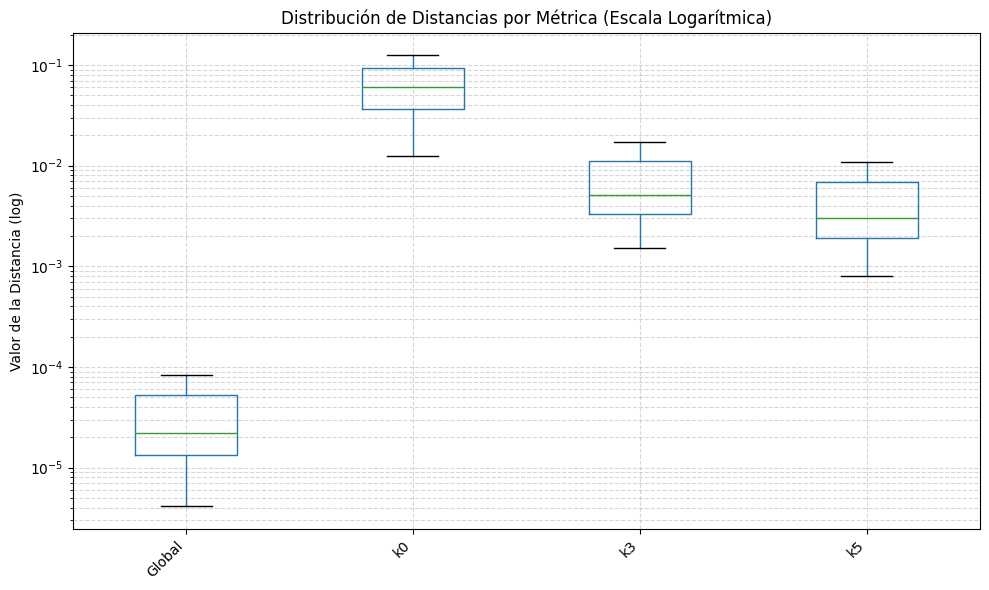


Top 10 — global_cosine_distance_to_WT
    mutant  position               group  global_cosine_distance_to_WT
3    R175E       175  Hotspots canónicos                      0.000082
62   R248G       248  Hotspots canónicos                      0.000077
116  R249D       249       Estructurales                      0.000075
119  R249G       249       Estructurales                      0.000075
2    R175D       175  Hotspots canónicos                      0.000074
136  R282E       282       Estructurales                      0.000064
45   G245K       245  Hotspots canónicos                      0.000060
57   R248A       248  Hotspots canónicos                      0.000059
71   R248S       248  Hotspots canónicos                      0.000059
51   G245R       245  Hotspots canónicos                      0.000059

Top 10 — k0_cosine_distance_to_WT
    mutant  position               group  k0_cosine_distance_to_WT
95   H179A       179       Estructurales                  0.124641
2    R175D 

In [ ]:
print("\n" + "=" * 70)
print("FASE 3: Cálculo de distancias coseno/euclidianas")
print("=" * 70)

wt_residue_reps = residue_reps[0]
wt_global_emb_mat = global_embedding_from_residue_matrix(wt_residue_reps).reshape(1, -1)

results = []
for i, m in enumerate(mutants, start=1):
    mut_rep = residue_reps[i]
    pos = m["position"]

    # --- Global ---
    mut_global = global_embedding_from_residue_matrix(mut_rep).reshape(1, -1)
    g_cos_sim = cosine_similarity(mut_global, wt_global_emb_mat)[0, 0]
    g_cos_dist = 1.0 - g_cos_sim
    g_euc_dist = euclidean_distances(mut_global, wt_global_emb_mat)[0, 0]

    # --- Local k=0 ---
    wt_k0 = residue_only_embedding(wt_residue_reps, pos).reshape(1, -1)
    mut_k0 = residue_only_embedding(mut_rep, pos).reshape(1, -1)
    k0_cos_sim = cosine_similarity(mut_k0, wt_k0)[0, 0]
    k0_cos_dist = 1.0 - k0_cos_sim
    k0_euc_dist = euclidean_distances(mut_k0, wt_k0)[0, 0]

    # --- Local k=3 ---
    wt_k3 = local_window_embedding(wt_residue_reps, pos, k=3).reshape(1, -1)
    mut_k3 = local_window_embedding(mut_rep, pos, k=3).reshape(1, -1)
    k3_cos_sim = cosine_similarity(mut_k3, wt_k3)[0, 0]
    k3_cos_dist = 1.0 - k3_cos_sim
    k3_euc_dist = euclidean_distances(mut_k3, wt_k3)[0, 0]

    # --- Local k=5 ---
    wt_k5 = local_window_embedding(wt_residue_reps, pos, k=5).reshape(1, -1)
    mut_k5 = local_window_embedding(mut_rep, pos, k=5).reshape(1, -1)
    k5_cos_sim = cosine_similarity(mut_k5, wt_k5)[0, 0]
    k5_cos_dist = 1.0 - k5_cos_sim
    k5_euc_dist = euclidean_distances(mut_k5, wt_k5)[0, 0]

    results.append({
        "mutant": m["mutant"],
        "position": m["position"],
        "wt_aa": m["wt_aa"],
        "mut_aa": m["mut_aa"],
        "group": m["group"],
        "global_cosine_similarity_to_WT": float(g_cos_sim),
        "global_cosine_distance_to_WT": float(g_cos_dist),
        "global_euclidean_distance_to_WT": float(g_euc_dist),
        "k0_cosine_similarity_to_WT": float(k0_cos_sim),
        "k0_cosine_distance_to_WT": float(k0_cos_dist),
        "k0_euclidean_distance_to_WT": float(k0_euc_dist),
        "k3_cosine_similarity_to_WT": float(k3_cos_sim),
        "k3_cosine_distance_to_WT": float(k3_cos_dist),
        "k3_euclidean_distance_to_WT": float(k3_euc_dist),
        "k5_cosine_similarity_to_WT": float(k5_cos_sim),
        "k5_cosine_distance_to_WT": float(k5_cos_dist),
        "k5_euclidean_distance_to_WT": float(k5_euc_dist),
    })

df = pd.DataFrame(results)
print(df.head().to_string())
print(f"\nDataFrame shape: {df.shape}")

# Métricas clave
metric_cols = [
    "global_cosine_distance_to_WT",
    "k0_cosine_distance_to_WT",
    "k3_cosine_distance_to_WT",
    "k5_cosine_distance_to_WT",
]

# Tabla comparativa de métricas
df_metric_comparison = df[metric_cols].describe().T
df_metric_comparison["metric"] = ["Global", "k0", "k3", "k5"]
df_metric_comparison = df_metric_comparison[["metric", "mean", "std", "min", "50%", "max"]]
print("\nResumen de métricas:")
print(df_metric_comparison.to_string())
df_metric_comparison.to_csv("metric_comparison.csv", index=False, float_format="%.2f")

# Boxplot de métricas (escala log)
plt.figure(figsize=(10, 6))
df_metric_comparison.set_index("metric")[["min", "50%", "max"]].T.boxplot()
plt.yscale("log")
plt.title("Distribución de Distancias por Métrica (Escala Logarítmica)")
plt.ylabel("Valor de la Distancia (log)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("metric_comparison_boxplot.svg")
plt.show()

# Top 10 mutantes más disruptivos por métrica
for col in metric_cols:
    print("\n" + "=" * 80)
    print(f"Top 10 — {col}")
    print(df.sort_values(col, ascending=False)[
        ["mutant", "position", "group", col]
    ].head(10).to_string())

# Resumen por posición
summary_by_position = (
    df.groupby(["group", "position", "wt_aa"], as_index=False)
    .agg(
        n_mutants=("mutant", "count"),
        global_mean=("global_cosine_distance_to_WT", "mean"),
        global_median=("global_cosine_distance_to_WT", "median"),
        global_std=("global_cosine_distance_to_WT", "std"),
        global_max=("global_cosine_distance_to_WT", "max"),
        k0_mean=("k0_cosine_distance_to_WT", "mean"),
        k0_median=("k0_cosine_distance_to_WT", "median"),
        k0_std=("k0_cosine_distance_to_WT", "std"),
        k0_max=("k0_cosine_distance_to_WT", "max"),
        k3_mean=("k3_cosine_distance_to_WT", "mean"),
        k3_median=("k3_cosine_distance_to_WT", "median"),
        k3_std=("k3_cosine_distance_to_WT", "std"),
        k3_max=("k3_cosine_distance_to_WT", "max"),
        k5_mean=("k5_cosine_distance_to_WT", "mean"),
        k5_median=("k5_cosine_distance_to_WT", "median"),
        k5_std=("k5_cosine_distance_to_WT", "std"),
        k5_max=("k5_cosine_distance_to_WT", "max"),
    )
)
summary_by_position["site"] = (
    summary_by_position["wt_aa"] + summary_by_position["position"].astype(str)
)


### FASE 4 — Visualización con reducción de dimensionalidad


FASE 4: Visualización (PCA, t-SNE, UMAP)
→ PCA de embeddings globales


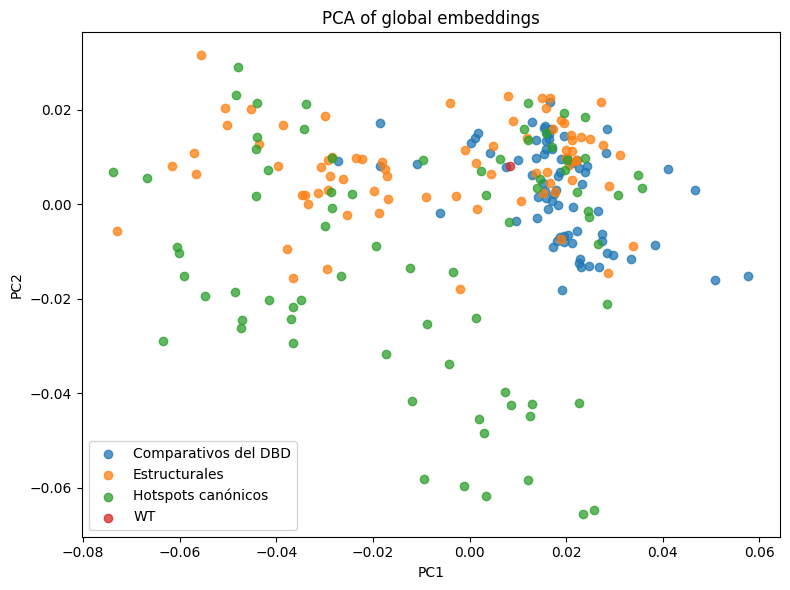

→ PCA de embeddings k=5


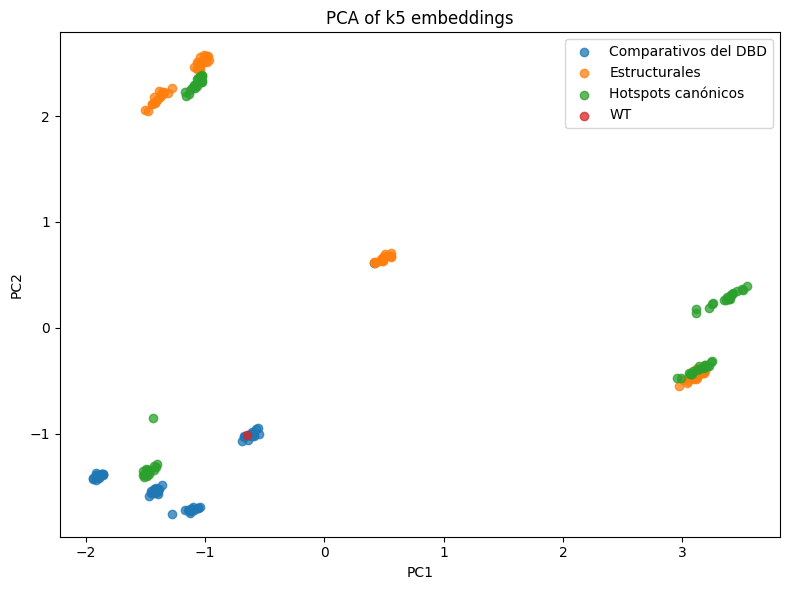

→ t-SNE de embeddings globales


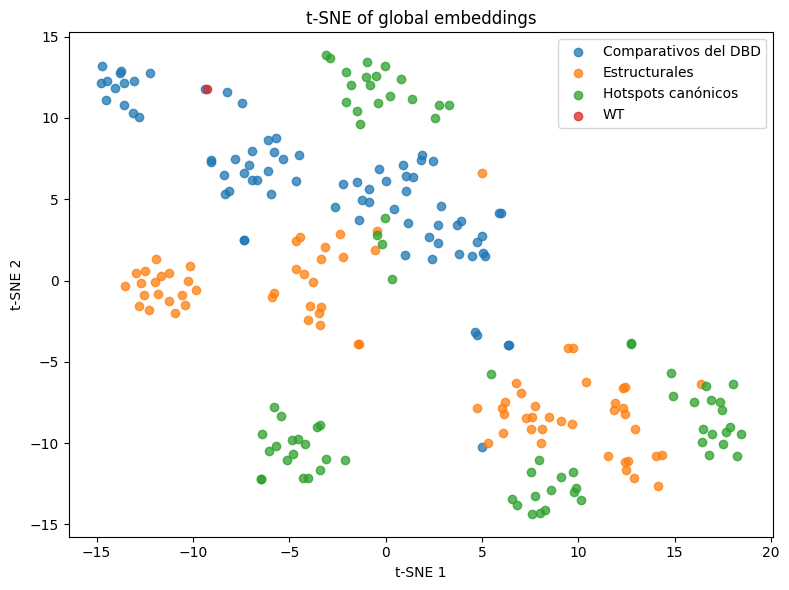

→ t-SNE de embeddings k=5


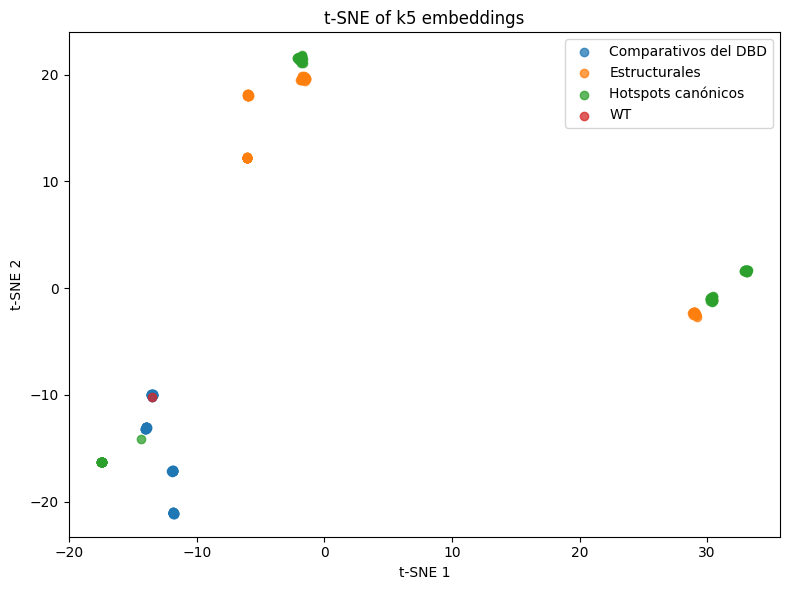

→ UMAP de embeddings globales


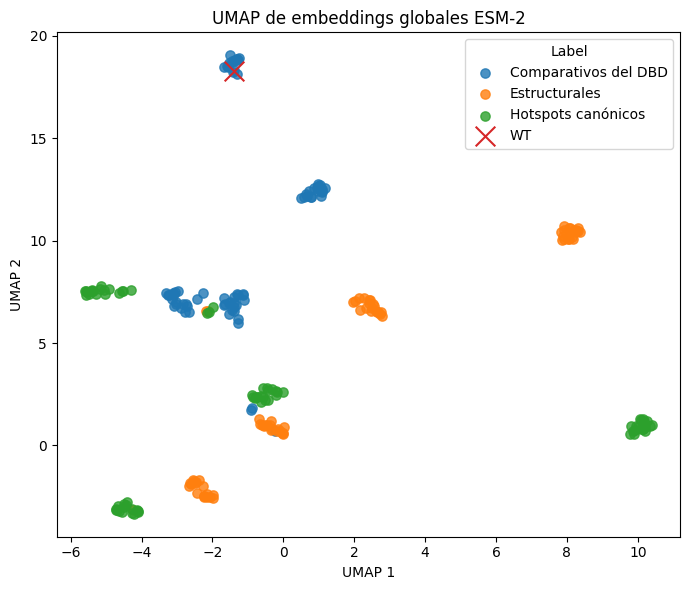

→ PCA(50) + UMAP de embeddings globales


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 640x480 with 0 Axes>

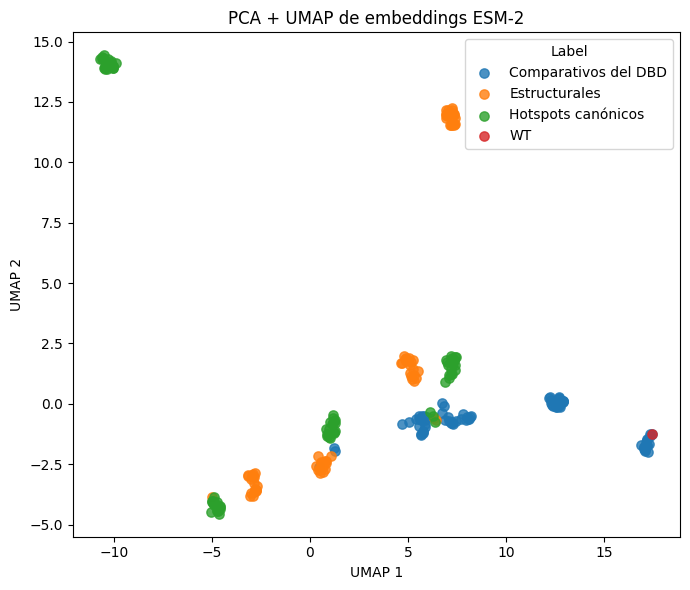

→ UMAP de embeddings k=5


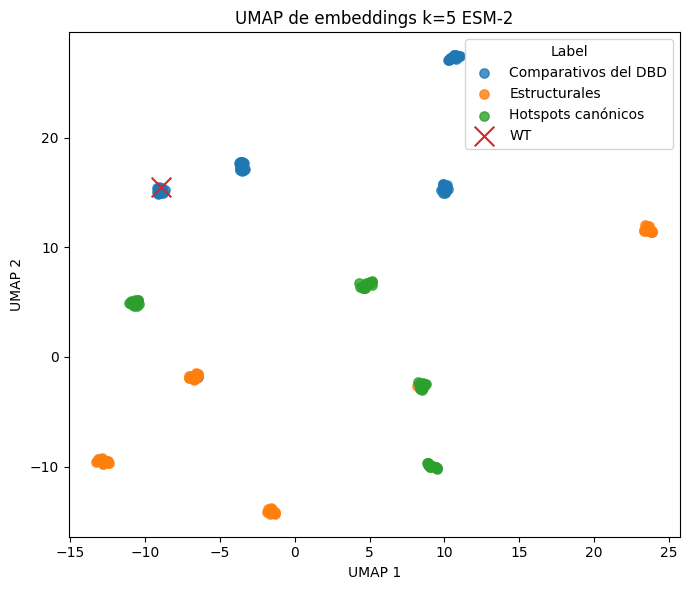

→ Boxplots de distancia coseno por grupo


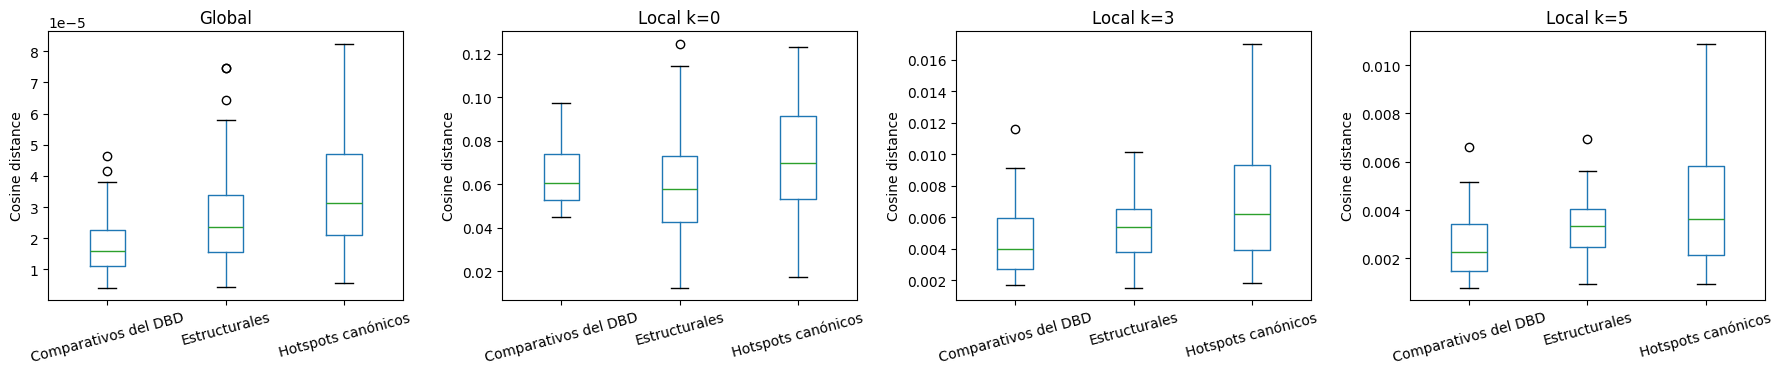

→ Heatmaps de distancia coseno


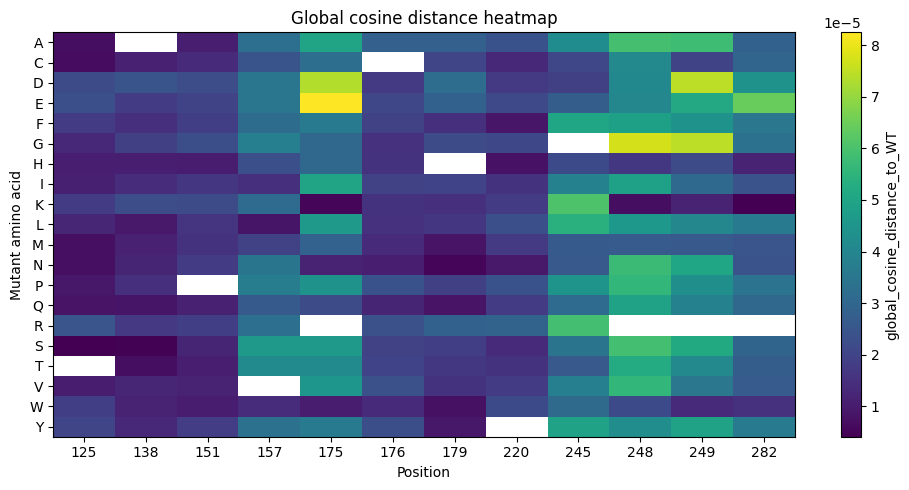

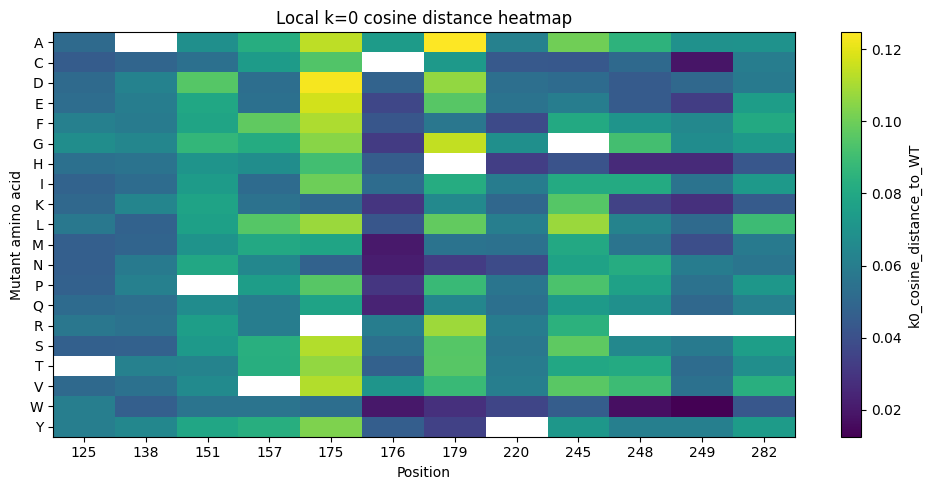

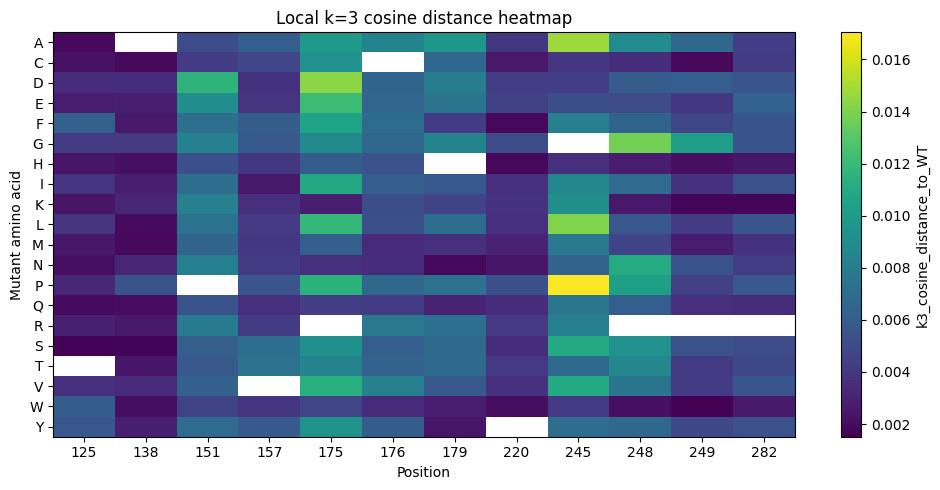

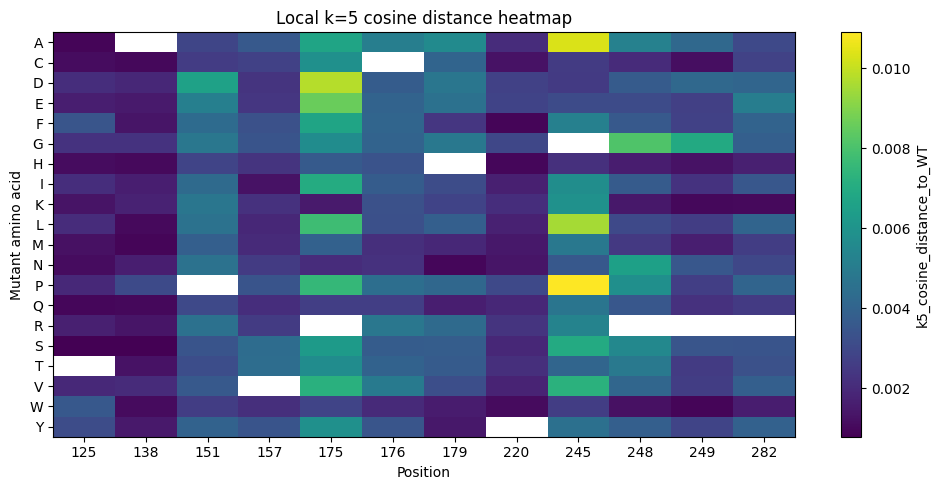

→ Sensibilidad promedio por posición (Global vs k=5)


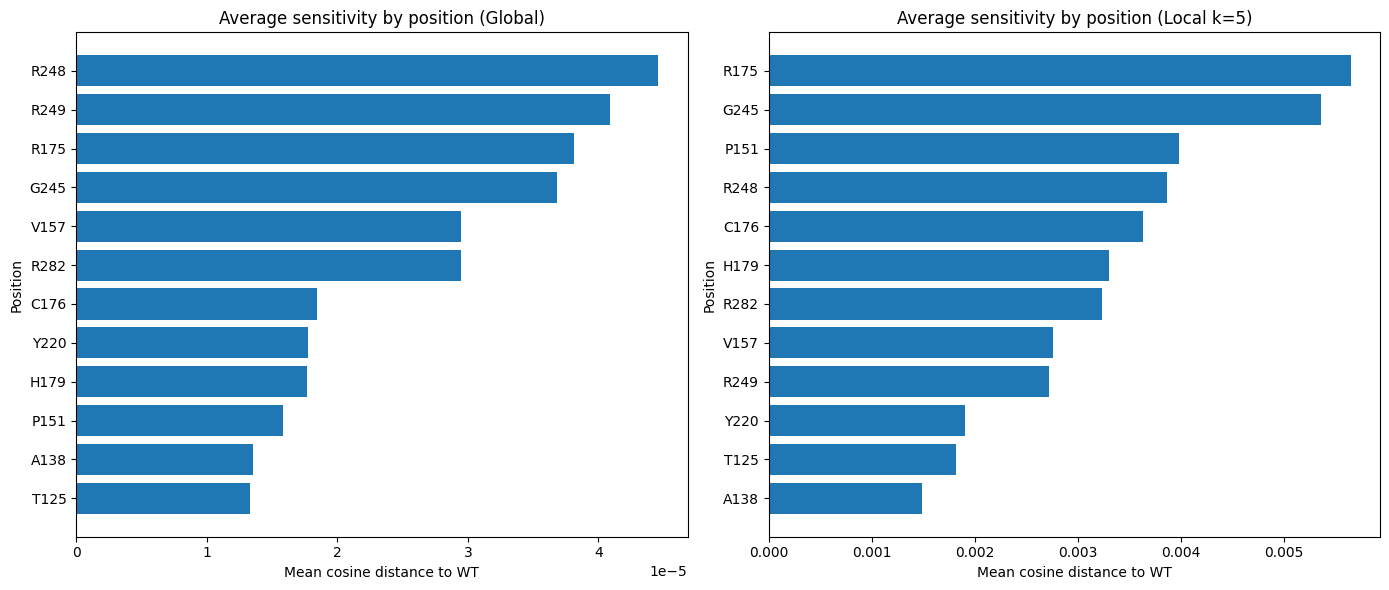

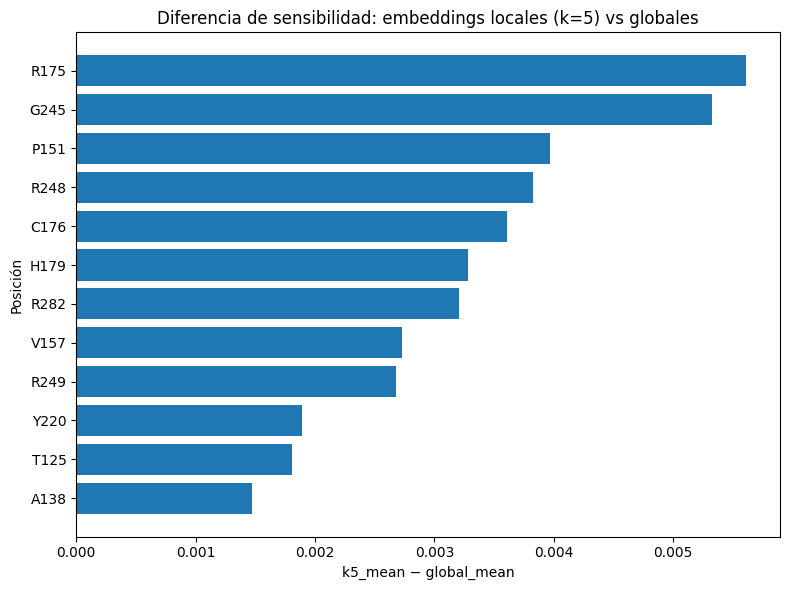

In [ ]:
print("\n" + "=" * 70)
print("FASE 4: Visualización (PCA, t-SNE, UMAP)")
print("=" * 70)

# -- PCA global --
print("→ PCA de embeddings globales")
pca = PCA(n_components=2)
coords = pca.fit_transform(global_emb)
plot_df = pd.DataFrame({
    "label": group_list,
    "PC1": coords[:, 0], "PC2": coords[:, 1],
    "group": group_list,
})
plt.figure(figsize=(8, 6))
for g in np.unique(group_list):
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA of global embeddings")
plt.legend()
plt.tight_layout()
plt.savefig("pca-global-embeddings.svg")
plt.show()

# -- PCA k5 --
print("→ PCA de embeddings k=5")
coords = PCA(n_components=2).fit_transform(k5_emb)
plot_df = pd.DataFrame({
    "label": group_list,
    "PC1": coords[:, 0], "PC2": coords[:, 1],
    "group": group_list,
})
plt.figure(figsize=(8, 6))
for g in np.unique(group_list):
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA of k5 embeddings")
plt.legend()
plt.tight_layout()
plt.savefig("pca-k5-embeddings.svg")
plt.show()

# -- t-SNE global --
print("→ t-SNE de embeddings globales")
coords = TSNE(n_components=2, random_state=42).fit_transform(global_emb)
plot_df = pd.DataFrame({
    "label": group_list,
    "PC1": coords[:, 0], "PC2": coords[:, 1],
    "group": group_list,
})
plt.figure(figsize=(8, 6))
for g in np.unique(group_list):
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("t-SNE of global embeddings")
plt.legend()
plt.tight_layout()
plt.savefig("tsne-global-embeddings.svg")
plt.show()

# -- t-SNE k5 --
print("→ t-SNE de embeddings k=5")
coords = TSNE(n_components=2, metric="cosine", random_state=42).fit_transform(k5_emb)
plot_df = pd.DataFrame({
    "label": group_list,
    "PC1": coords[:, 0], "PC2": coords[:, 1],
    "group": group_list,
})
plt.figure(figsize=(8, 6))
for g in np.unique(group_list):
    sub = plot_df[plot_df["group"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("t-SNE of k5 embeddings")
plt.legend()
plt.tight_layout()
plt.savefig("tsne-k5-embeddings.svg")
plt.show()

# -- UMAP global --
print("→ UMAP de embeddings globales")
plot_umap_by_label(global_emb, group_list, "UMAP de embeddings globales ESM-2")
plt.savefig("umap-global-embeddings.svg")

# -- PCA+UMAP --
print("→ PCA(50) + UMAP de embeddings globales")
X_scaled = StandardScaler().fit_transform(global_emb)
X_pca = PCA(n_components=50, random_state=42).fit_transform(X_scaled)
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric="cosine", random_state=42)
X_umap = reducer.fit_transform(X_pca)
df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0], "UMAP2": X_umap[:, 1], "label": group_list,
})
plt.figure(figsize=(7, 6))
for lbl in np.unique(group_list):
    subset = df_umap[df_umap["label"] == lbl]
    plt.scatter(subset["UMAP1"], subset["UMAP2"], label=lbl, alpha=0.8, s=45)
plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
plt.title("PCA + UMAP de embeddings ESM-2")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

# -- UMAP k5 --
print("→ UMAP de embeddings k=5")
plot_umap_by_label(k5_emb, group_list, "UMAP de embeddings k=5 ESM-2")

# -- Boxplots por grupo --
print("→ Boxplots de distancia coseno por grupo")
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
plot_map = [
    ("global_cosine_distance_to_WT", "Global"),
    ("k0_cosine_distance_to_WT", "Local k=0"),
    ("k3_cosine_distance_to_WT", "Local k=3"),
    ("k5_cosine_distance_to_WT", "Local k=5"),
]
for ax, (col, title) in zip(axes, plot_map):
    df.boxplot(column=col, by="group", grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Cosine distance")
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("")
plt.tight_layout()
plt.show()

# -- Heatmaps --
print("→ Heatmaps de distancia coseno")
plot_heatmap(df, "global_cosine_distance_to_WT", "Global cosine distance heatmap")
plot_heatmap(df, "k0_cosine_distance_to_WT", "Local k=0 cosine distance heatmap")
plot_heatmap(df, "k3_cosine_distance_to_WT", "Local k=3 cosine distance heatmap")
plot_heatmap(df, "k5_cosine_distance_to_WT", "Local k=5 cosine distance heatmap")

# -- Barras de sensibilidad promedio -- #Ya no se uso
"""
print("→ Sensibilidad promedio por posición (Global vs k=5)")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
tmp = summary_by_position.sort_values("global_mean", ascending=True)
axes[0].barh(tmp["site"], tmp["global_mean"])
axes[0].set_title("Average sensitivity by position (Global)")
axes[0].set_xlabel("Mean cosine distance to WT")
axes[0].set_ylabel("Position")
tmp = summary_by_position.sort_values("k5_mean", ascending=True)
axes[1].barh(tmp["site"], tmp["k5_mean"])
axes[1].set_title("Average sensitivity by position (Local k=5)")
axes[1].set_xlabel("Mean cosine distance to WT")
axes[1].set_ylabel("Position")
plt.tight_layout()
plt.savefig("average-sensitivity-by-position-global-vs-k5.svg")
plt.show()
"""

# -- Delta k5 vs global --
compare_rank = summary_by_position[["site", "group", "global_mean", "k5_mean"]].copy()
compare_rank["delta_k5_minus_global"] = compare_rank["k5_mean"] - compare_rank["global_mean"]
compare_rank = compare_rank.sort_values("delta_k5_minus_global", ascending=False)

tmp = compare_rank.sort_values("delta_k5_minus_global", ascending=True)
plt.figure(figsize=(8, 6))
plt.barh(tmp["site"], tmp["delta_k5_minus_global"])
plt.xlabel("k5_mean − global_mean")
plt.ylabel("Posición")
plt.title("Diferencia de sensibilidad: embeddings locales (k=5) vs globales")
plt.tight_layout()
plt.savefig("compare_rank.svg")
plt.show()

compare_rank.to_csv("compare_rank.csv", index=False)


### FASE 5 — Anotación fisicoquímica y pruebas de Mann–Whitney


FASE 5: Anotación fisicoquímica y pruebas estadísticas
  mutant  position wt_aa mut_aa               group  global_cosine_similarity_to_WT  global_cosine_distance_to_WT  global_euclidean_distance_to_WT  k0_cosine_similarity_to_WT  k0_cosine_distance_to_WT  k0_euclidean_distance_to_WT  k3_cosine_similarity_to_WT  k3_cosine_distance_to_WT  k3_euclidean_distance_to_WT  k5_cosine_similarity_to_WT  k5_cosine_distance_to_WT  k5_euclidean_distance_to_WT wt_charge mut_charge wt_class    mut_class wt_size mut_size  charge_change  class_change  size_change  introduces_proline  introduces_glycine  introduces_cysteine  removes_proline  removes_glycine  removes_cysteine  wt_aromatic  mut_aromatic  aromatic_change wt_hydro_group mut_hydro_group  hydro_group_change  is_conservative_like
0  R175A       175     R      A  Hotspots canónicos                        0.999950                      0.000050                         0.086051                    0.886312                  0.113688                

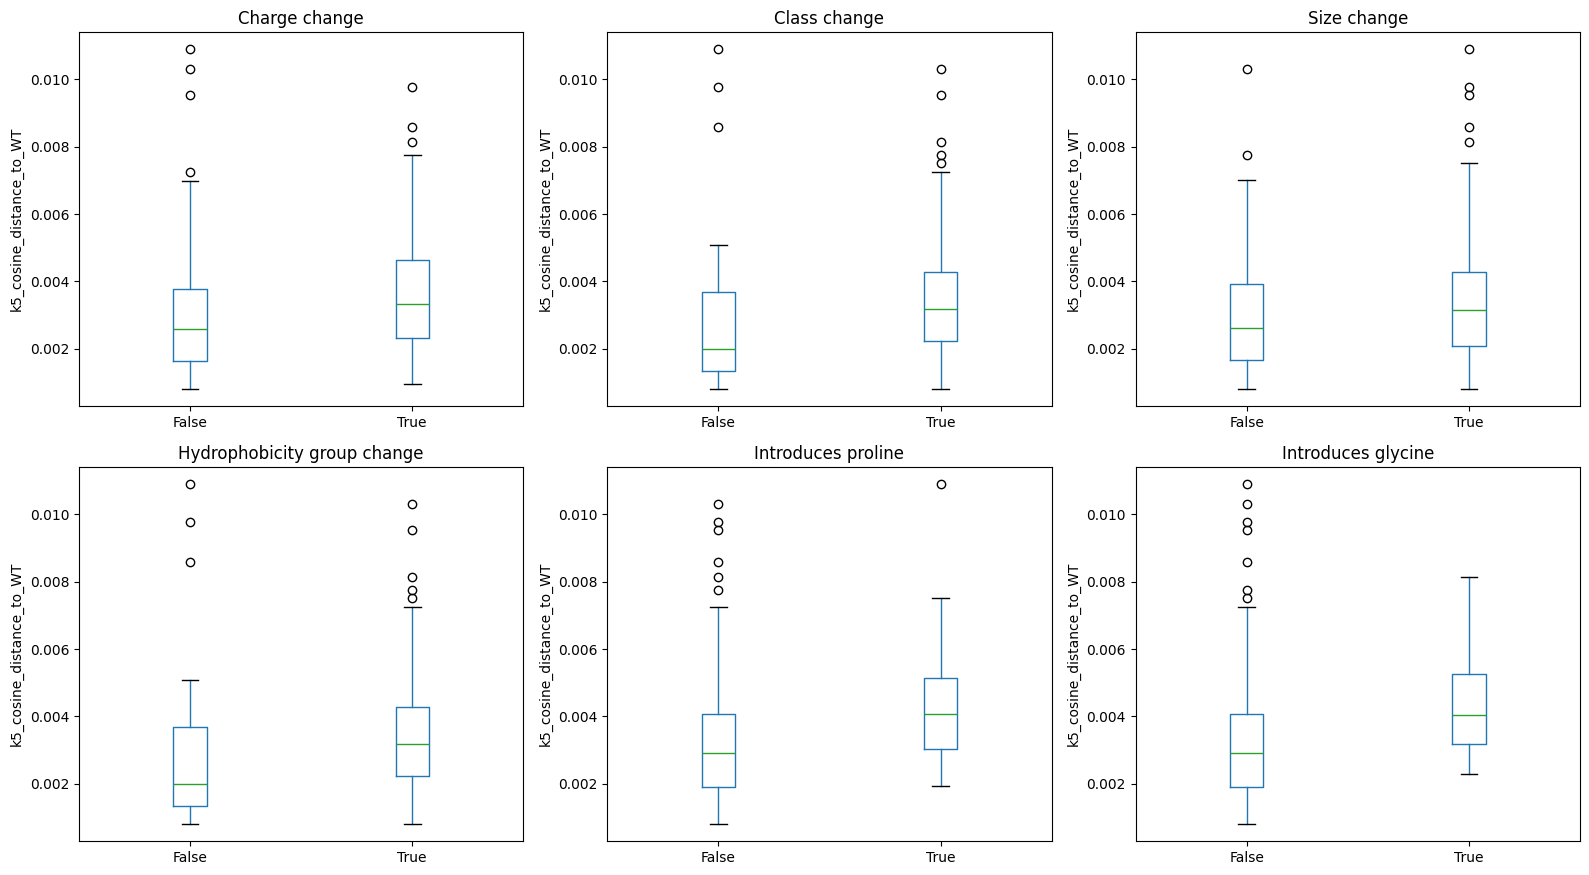


Resultados Mann–Whitney:
                   flag  median_false  median_true  median_diff_true_minus_false  rank_biserial effect_size_label   p_value  p_adj_bh significant_bh_0_05
8  is_conservative_like      0.003111     0.001283                     -0.001828      -0.733025             large  0.000020  0.000177                True
1          class_change      0.001980     0.003166                      0.001186       0.318932          moderate  0.000526  0.001579                True
3    hydro_group_change      0.001980     0.003166                      0.001186       0.318932          moderate  0.000526  0.001579                True
0         charge_change      0.002596     0.003336                      0.000740       0.256636             small  0.000829  0.001865                True
7       aromatic_change      0.003193     0.002623                     -0.000570      -0.220674             small  0.017238  0.031028                True
5    introduces_glycine      0.002896     0.004028

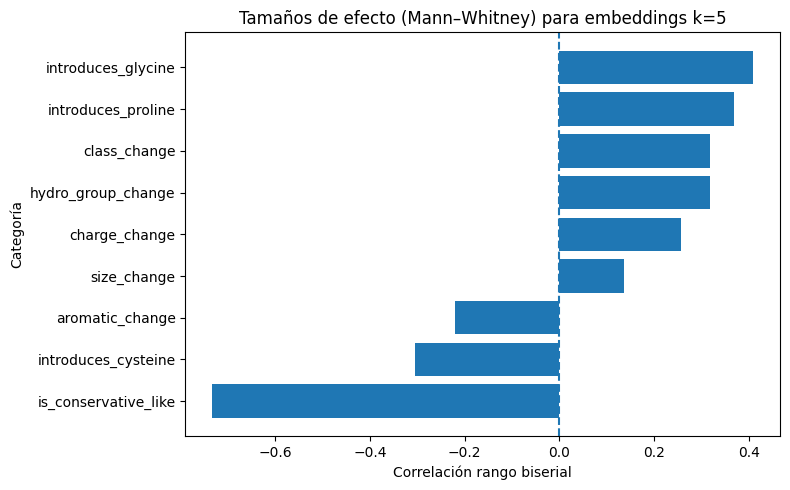


Archivos guardados de Fase 5:
  - tp53_synthetic_mutants_embedding_metrics_annotated.csv
  - tp53_mannwhitney_k5_results.csv
  - tp53_mutation_type_summary_k5.csv


In [ ]:
print("\n" + "=" * 70)
print("FASE 5: Anotación fisicoquímica y pruebas estadísticas")
print("=" * 70)

df_annot = annotate_mutation_type(df)
print(df_annot.head().to_string())

# Resumen de banderas
flag_cols = [
    "charge_change", "class_change", "size_change",
    "hydro_group_change", "introduces_proline",
    "introduces_glycine", "introduces_cysteine",
    "aromatic_change", "is_conservative_like",
]
for k in flag_cols:
    print(f"\n{k}:")
    print(df_annot[k].value_counts().to_string())

# Boxplots de k5 por categoría
metric = "k5_cosine_distance_to_WT"
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ("charge_change", "Charge change"),
    ("class_change", "Class change"),
    ("size_change", "Size change"),
    ("hydro_group_change", "Hydrophobicity group change"),
    ("introduces_proline", "Introduces proline"),
    ("introduces_glycine", "Introduces glycine"),
]
for ax, (col, title) in zip(axes.flatten(), plot_specs):
    df_annot.boxplot(column=metric, by=col, grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)
plt.suptitle("")
plt.tight_layout()
plt.savefig("boxplot-categories-vs-k5-cosine-distance.svg")
plt.show()

# Pruebas de Mann–Whitney
mw_results = pd.DataFrame([
    mann_whitney_for_flag(df_annot, col, metric) for col in flag_cols
])
valid_mask = mw_results["p_value"].notna()
rej, p_adj, _, _ = multipletests(
    mw_results.loc[valid_mask, "p_value"].values,
    alpha=0.05, method="fdr_bh"
)
mw_results.loc[valid_mask, "p_adj_bh"] = p_adj
mw_results.loc[valid_mask, "significant_bh_0_05"] = rej
mw_results = mw_results.sort_values("p_adj_bh", ascending=True)

# Añadir interpretación de tamaño de efecto
mw_results["effect_size_label"] = mw_results["rank_biserial"].apply(
    lambda x: interpret_rbc(x) if pd.notna(x) else np.nan
)
mw_interpret = mw_results[[
    "flag", "median_false", "median_true",
    "median_diff_true_minus_false", "rank_biserial",
    "effect_size_label", "p_value", "p_adj_bh", "significant_bh_0_05",
]].sort_values("p_adj_bh")
print("\nResultados Mann–Whitney:")
print(mw_interpret.to_string())
mw_interpret.to_csv("mannwhitney_k5_results.csv", index=False, encoding="utf-8")

# Visualización de tamaños de efecto
tmp = mw_results.sort_values("rank_biserial", ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(tmp["flag"], tmp["rank_biserial"])
plt.axvline(0, linestyle="--")
plt.xlabel("Correlación rango biserial")
plt.ylabel("Categoría")
plt.title("Tamaños de efecto (Mann–Whitney) para embeddings k=5")
plt.tight_layout()
plt.savefig("mannwhitney-effect-sizes-k5-cosine.svg")
plt.show()

# Guardar resultados
df_annot.to_csv("tp53_synthetic_mutants_embedding_metrics_annotated.csv", index=False)
mw_results.to_csv("tp53_mannwhitney_k5_results.csv", index=False)
summary_flags_df = pd.concat([
    summarize_by_flag(df_annot, col, metric) for col in flag_cols
], ignore_index=True)
summary_flags_df.to_csv("tp53_mutation_type_summary_k5.csv", index=False)

print("\nArchivos guardados de Fase 5:")
print("  - tp53_synthetic_mutants_embedding_metrics_annotated.csv")
print("  - tp53_mannwhitney_k5_results.csv")
print("  - tp53_mutation_type_summary_k5.csv")


### FASE 6 — Scores funcionales de MAVEDB


FASE 6: Scores funcionales reales desde MAVEDB
Title: Combined score using three assays of TP53 activity that assess loss of function or dominant negative effect
URN: urn:mavedb:00000068-0-1
Shape: (8258, 5)
Columns: ['accession', 'hgvs_nt', 'hgvs_splice', 'hgvs_pro', 'score']

Variant column: hgvs_pro
Score column: score
Mutantes parseados: 7880
MAVE missense shape: (7467, 2)
Overlap con panel: (228, 16)
Posiciones con datos reales:
position
125    19
138    19
151    19
157    19
175    19
176    19
179    19
220    19
245    19
248    19
249    19
282    19
Name: count, dtype: int64

Verificación de orientación del score (mutantes dañinos canónicos):
    mutant  score_raw  k5_cosine_distance_to_WT
52   G245S   0.771774                  0.006983
6    R175H   1.024850                  0.003658
70   R248Q   0.811973                  0.003552
74   R248W   0.951960                  0.001252
150  R282W   1.025667                  0.001606
  → Si estos mutantes tienen scores bajos, score_

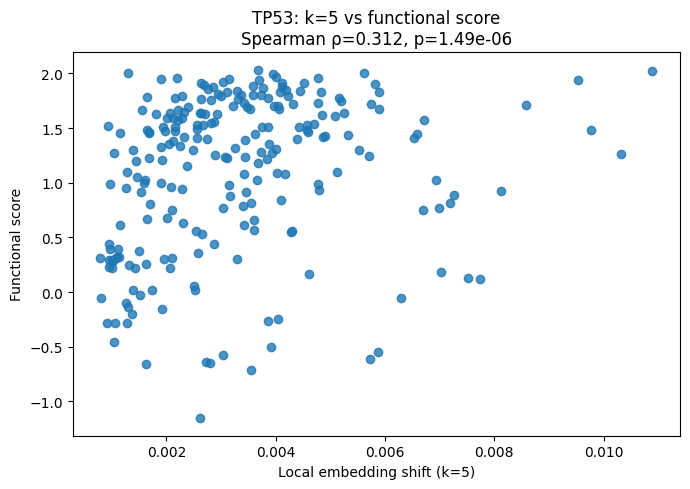

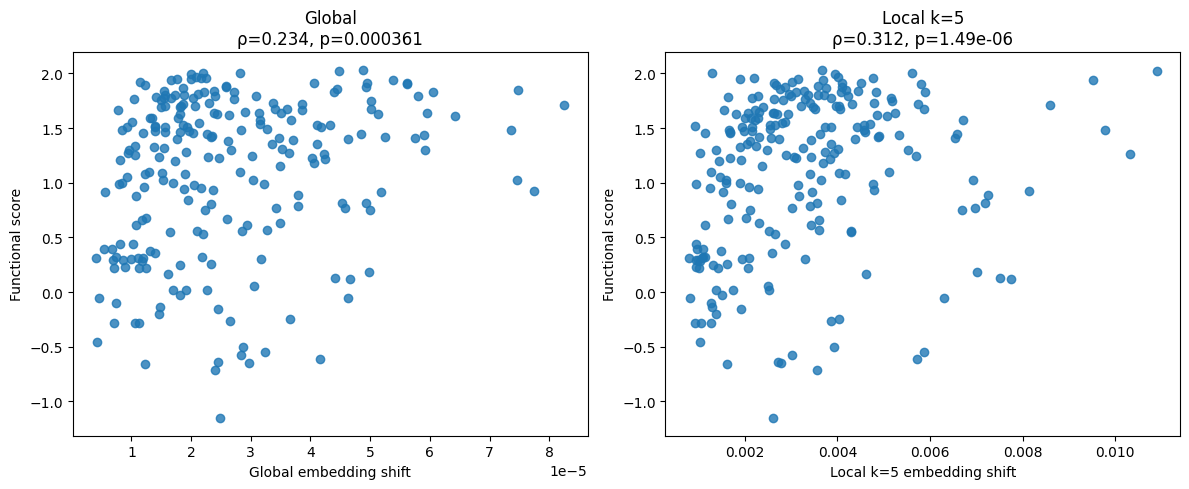

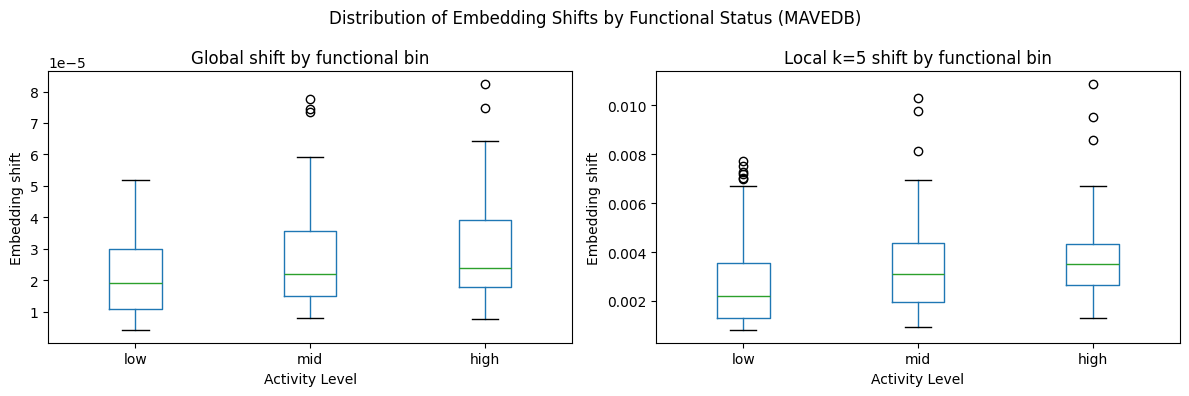


Mann–Whitney low vs high on k5:
  n_low = 76, n_high = 76
  U = 1725.0, p = 1.837680947876241e-05
  median_low = 0.002208, median_high = 0.003494

Archivos guardados de Fase 6:
  - tp53_panel_functional_correlations.csv
  - tp53_panel_with_functional_scores.csv


In [ ]:
print("\n" + "=" * 70)
print("FASE 6: Scores funcionales reales desde MAVEDB")
print("=" * 70)

base_url = "https://api.mavedb.org/api/v1"
url_scores = f"{base_url}/score-sets/{MAVEDB_URN}/scores"
url_meta = f"{base_url}/score-sets/{MAVEDB_URN}"

meta = requests.get(url_meta, timeout=60)
meta.raise_for_status()
meta_json = meta.json()

scores = requests.get(url_scores, timeout=60)
scores.raise_for_status()
mave_raw = pd.read_csv(io.StringIO(scores.text))

print(f"Title: {meta_json.get('title', 'N/A')}")
print(f"URN: {MAVEDB_URN}")
print(f"Shape: {mave_raw.shape}")
print(f"Columns: {list(mave_raw.columns)}")

# Detectar columnas automáticamente
variant_candidates = [
    "hgvs_pro", "hgvs_p", "protein_variant", "variant",
    "aa_variant", "amino_acid_change", "protein_change",
]
score_candidates = [
    "score", "main_score", "functional_score",
    "score_value", "normalized_score",
]
variant_col = pick_first_existing(mave_raw.columns, variant_candidates)
score_col = pick_first_existing(mave_raw.columns, score_candidates)
print(f"\nVariant column: {variant_col}")
print(f"Score column: {score_col}")

if variant_col is None or score_col is None:
    raise ValueError("No se pudieron detectar columnas de variante/score en MAVEDB.")

# Parsear mutantes
mave = mave_raw.copy()
mave["mutant"] = mave[variant_col].apply(normalize_protein_variant)
mave["score_raw"] = pd.to_numeric(mave[score_col], errors="coerce")
print(f"Mutantes parseados: {mave['mutant'].notna().sum()}")

# Filtrar solo missense
missense_pattern = re.compile(r"^[ACDEFGHIKLMNPQRSTVWY](\d+)[ACDEFGHIKLMNPQRSTVWY]$")
mave_missense = mave[
    mave["mutant"].notna() &
    mave["mutant"].str.match(missense_pattern) &
    mave["score_raw"].notna()
].copy()
mave_missense = mave_missense.groupby("mutant", as_index=False).agg(
    score_raw=("score_raw", "mean")
)
print(f"MAVE missense shape: {mave_missense.shape}")

# Merge con nuestros datos
merge_cols = [
    "mutant", "position", "wt_aa", "mut_aa", "group",
    "global_cosine_distance_to_WT", "k0_cosine_distance_to_WT",
    "k3_cosine_distance_to_WT", "k5_cosine_distance_to_WT",
    "class_change", "hydro_group_change", "is_conservative_like",
    "introduces_glycine", "introduces_proline", "introduces_cysteine",
]
tp53_panel = df_annot[merge_cols].merge(mave_missense, on="mutant", how="inner")
print(f"Overlap con panel: {tp53_panel.shape}")
print(f"Posiciones con datos reales:\n{tp53_panel['position'].value_counts().sort_index()}")

# Verificar orientación del score con mutantes canónicos dañinos
canonical_bad = ["R175H", "G245S", "R248Q", "R248W", "R273H", "R282W"]
check = tp53_panel[tp53_panel["mutant"].isin(canonical_bad)][
    ["mutant", "score_raw", "k5_cosine_distance_to_WT"]
].sort_values("mutant")
print("\nVerificación de orientación del score (mutantes dañinos canónicos):")
print(check.to_string())
print("  → Si estos mutantes tienen scores bajos, score_raw ya es 'más funcional = mayor'.")
print("  → Si tienen scores altos, será necesario invertir el signo.")

flip_score = False
tp53_panel["functional_score"] = (
    -tp53_panel["score_raw"] if flip_score else tp53_panel["score_raw"]
)

# Correlaciones embedding vs score funcional
corr_table = pd.DataFrame([
    correlation_report(tp53_panel, "global_cosine_distance_to_WT",
                       "functional_score", "global"),
    correlation_report(tp53_panel, "k3_cosine_distance_to_WT",
                       "functional_score", "k3"),
    correlation_report(tp53_panel, "k5_cosine_distance_to_WT",
                       "functional_score", "k5"),
])
print("\nCorrelaciones embedding vs score funcional:")
print(corr_table.to_string())
corr_table.to_csv("correlation-embedding-table.csv", index=False)

# Scatter plot k5 vs functional score
x = tp53_panel["k5_cosine_distance_to_WT"].values
y = tp53_panel["functional_score"].values
rho, pval = spearmanr(x, y)
plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("Local embedding shift (k=5)")
plt.ylabel("Functional score")
plt.title(f"TP53: k=5 vs functional score\nSpearman ρ={rho:.3f}, p={pval:.3g}")
plt.tight_layout()
plt.savefig("embedding-vs-functional-score-k5.svg")
plt.show()

# Scatter global vs k5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (col, title) in zip(axes, [
    ("global_cosine_distance_to_WT", "Global"),
    ("k5_cosine_distance_to_WT", "Local k=5"),
]):
    x = tp53_panel[col].values
    y = tp53_panel["functional_score"].values
    rho, pval = spearmanr(x, y)
    ax.scatter(x, y, alpha=0.8)
    ax.set_xlabel(f"{title} embedding shift")
    ax.set_ylabel("Functional score")
    ax.set_title(f"{title}\nρ={rho:.3f}, p={pval:.3g}")
plt.tight_layout()
plt.savefig("embedding-vs-functional-score-global-k5.svg")
plt.show()

# Boxplots por terciles funcionales
tp53_panel["functional_bin"] = pd.qcut(
    tp53_panel["functional_score"], q=3, labels=["low", "mid", "high"]
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tp53_panel.boxplot(column="global_cosine_distance_to_WT",
                   by="functional_bin", grid=False, ax=axes[0])
axes[0].set_title("Global shift by functional bin")
axes[0].set_xlabel("Activity Level")
axes[0].set_ylabel("Embedding shift")
tp53_panel.boxplot(column="k5_cosine_distance_to_WT",
                   by="functional_bin", grid=False, ax=axes[1])
axes[1].set_title("Local k=5 shift by functional bin")
axes[1].set_xlabel("Activity Level")
axes[1].set_ylabel("Embedding shift")
plt.suptitle("Distribution of Embedding Shifts by Functional Status (MAVEDB)")
plt.tight_layout()
plt.savefig("histogram-embeding-shift.svg")
plt.show()

# MW low vs high
low = tp53_panel.loc[tp53_panel["functional_bin"] == "low",
                     "k5_cosine_distance_to_WT"].values
high = tp53_panel.loc[tp53_panel["functional_bin"] == "high",
                      "k5_cosine_distance_to_WT"].values
u, p = mannwhitneyu(low, high, alternative="two-sided")
print(f"\nMann–Whitney low vs high on k5:")
print(f"  n_low = {len(low)}, n_high = {len(high)}")
print(f"  U = {u}, p = {p}")
print(f"  median_low = {np.median(low):.6f}, median_high = {np.median(high):.6f}")

corr_table.to_csv("tp53_panel_functional_correlations.csv", index=False)
tp53_panel.to_csv("tp53_panel_with_functional_scores.csv", index=False)
print("\nArchivos guardados de Fase 6:")
print("  - tp53_panel_functional_correlations.csv")
print("  - tp53_panel_with_functional_scores.csv")


### FASE 7 — Comparación ESM2 vs BLOSUM62

In [ ]:
print("\n" + "=" * 70)
print("FASE 7: Comparación ESM2 vs BLOSUM62 como predictor de patogenicidad")
print("=" * 70)

# Añadir scores BLOSUM
blosum62 = substitution_matrices.load("BLOSUM62")
tp53_panel["blosum62_score"] = [
    get_blosum_score(w, m, blosum62)
    for w, m in zip(tp53_panel["wt_aa"], tp53_panel["mut_aa"])
]

# Preparar columnas para comparación
df_cmp = tp53_panel.copy()
df_cmp["target"] = df_cmp["score_raw"]
df_cmp["esm_badness"] = df_cmp["k5_cosine_distance_to_WT"]
df_cmp["blosum_badness"] = df_cmp["blosum62_score"]

# Correlaciones comparativas
corr_compare = pd.DataFrame([
    correlation_report(df_cmp, "blosum_badness", "target", "BLOSUM62 vs score"),
    correlation_report(df_cmp, "esm_badness", "target", "ESM k=5 vs score"),
])
print("\nComparación ESM vs BLOSUM:")
print(corr_compare.to_string())


FASE 7: Comparación ESM2 vs BLOSUM62 como predictor de patogenicidad

Comparación ESM vs BLOSUM:
               label    n  spearman_rho  spearman_p  pearson_r  pearson_p  kendall_tau  kendall_p
0  BLOSUM62 vs score  228      0.298836    0.000004   0.286127   0.000011     0.222308   0.000005
1   ESM k=5 vs score  228      0.312432    0.000001   0.229736   0.000471     0.217173   0.000001


In [ ]:
# Benchmark table
benchmark_table = pd.DataFrame([
    correlation_report(df_cmp, "blosum62_score", "target", "BLOSUM62 (raw)"),
    correlation_report(df_cmp, "global_cosine_distance_to_WT", "target", "ESM global"),
    correlation_report(df_cmp, "k5_cosine_distance_to_WT", "target", "ESM local k=5"),
])
print("\nBenchmark completo:")
benchmark_table


Benchmark completo:


,label,n,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p
0,BLOSUM62 (raw),228,0.298836,0.000004,0.286127,0.000011,0.222308,0.000005
1,ESM global,228,0.234215,0.000361,0.222980,0.000696,0.159991,0.000325
2,ESM local k=5,228,0.312432,0.000001,0.229736,0.000471,0.217173,0.000001


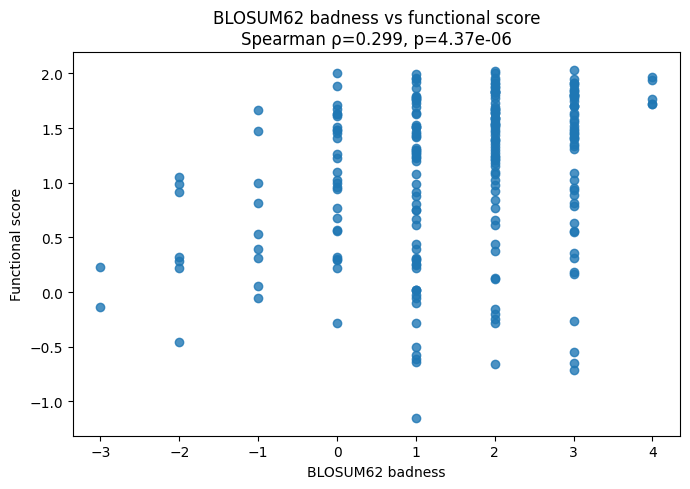

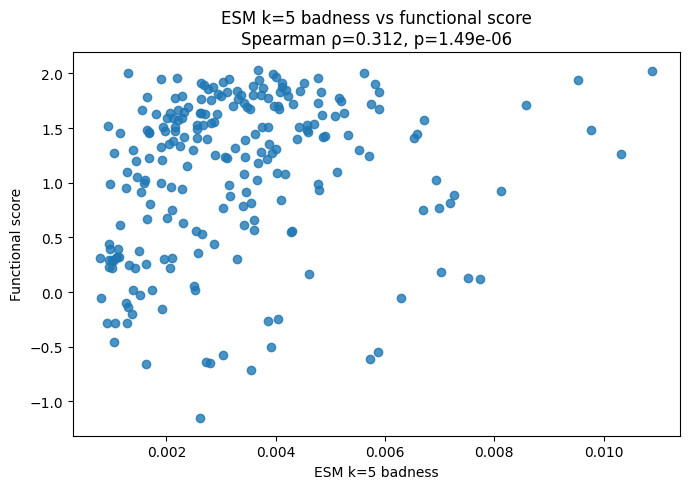

In [ ]:

# Scatter plots comparativos
for x_col, x_label in [
    ("blosum_badness", "BLOSUM62 badness"),
    ("esm_badness", "ESM k=5 badness"),
]:
    x = df_cmp[x_col].values
    y = df_cmp["target"].values
    rho, pval = spearmanr(x, y)
    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.8)
    plt.xlabel(x_label)
    plt.ylabel("Functional score")
    plt.title(f"{x_label} vs functional score\nSpearman ρ={rho:.3f}, p={pval:.3g}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Subgroup analysis: ¿dónde gana ESM sobre BLOSUM?
global_cmp = pd.DataFrame([subgroup_spearman(df_cmp, "all_mutants", min_n=10)])


In [ ]:

# Por grupo
group_results = pd.DataFrame([
    subgroup_spearman(subdf, f"group={g}", min_n=10)
    for g, subdf in df_cmp.groupby("group")
]).sort_values("delta_rho_esm_minus_blosum", ascending=False)

group_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
0,group=Comparativos del DBD,76,0.623486,1.790422e-09,0.277236,0.015327,0.346250
1,group=Estructurales,76,0.099084,3.944487e-01,0.250230,0.029249,-0.151146
2,group=Hotspots canónicos,76,0.064634,5.790924e-01,0.366227,0.001140,-0.301593


In [ ]:

# Por banderas
flag_results = []
for col in ["class_change", "is_conservative_like", "introduces_glycine",
            "introduces_proline", "introduces_cysteine"]:
    for val in [True, False]:
        subdf = df_cmp[df_cmp[col] == val]
        flag_results.append(subgroup_spearman(subdf, f"{col}={val}", min_n=10))
flag_results = pd.DataFrame(flag_results).sort_values(
    "delta_rho_esm_minus_blosum", ascending=False
)

flag_results

,subset,n,rho_esm,p_esm,rho_blosum,p_blosum,delta_rho_esm_minus_blosum
1,class_change=False,51,0.629774,7.376823e-07,0.413988,2.528278e-03,0.215785
5,introduces_glycine=False,217,0.326141,9.034750e-07,0.300188,6.771741e-06,0.025953
7,introduces_proline=False,217,0.312103,2.750063e-06,0.290187,1.399925e-05,0.021916
3,is_conservative_like=False,216,0.263137,9.075200e-05,0.254128,1.597525e-04,0.009009
9,introduces_cysteine=False,217,0.312329,2.702284e-06,0.330398,6.374599e-07,-0.018069
2,is_conservative_like=True,12,0.706294,1.024519e-02,0.746474,5.290242e-03,-0.040180
0,class_change=True,177,0.221538,3.042614e-03,0.288134,1.006485e-04,-0.066597
4,introduces_glycine=True,11,-0.145455,6.695786e-01,0.021320,9.503887e-01,-0.166775
6,introduces_proline=True,11,0.236364,4.840912e-01,0.429058,1.878976e-01,-0.192695
8,introduces_cysteine=True,11,-0.254545,4.500366e-01,0.295721,3.772792e-01,-0.550267


/tmp/ipykernel_9236/756076865.py:133: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])
/tmp/ipykernel_9236/756076865.py:133: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])
/tmp/ipykernel_9236/756076865.py:133: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])


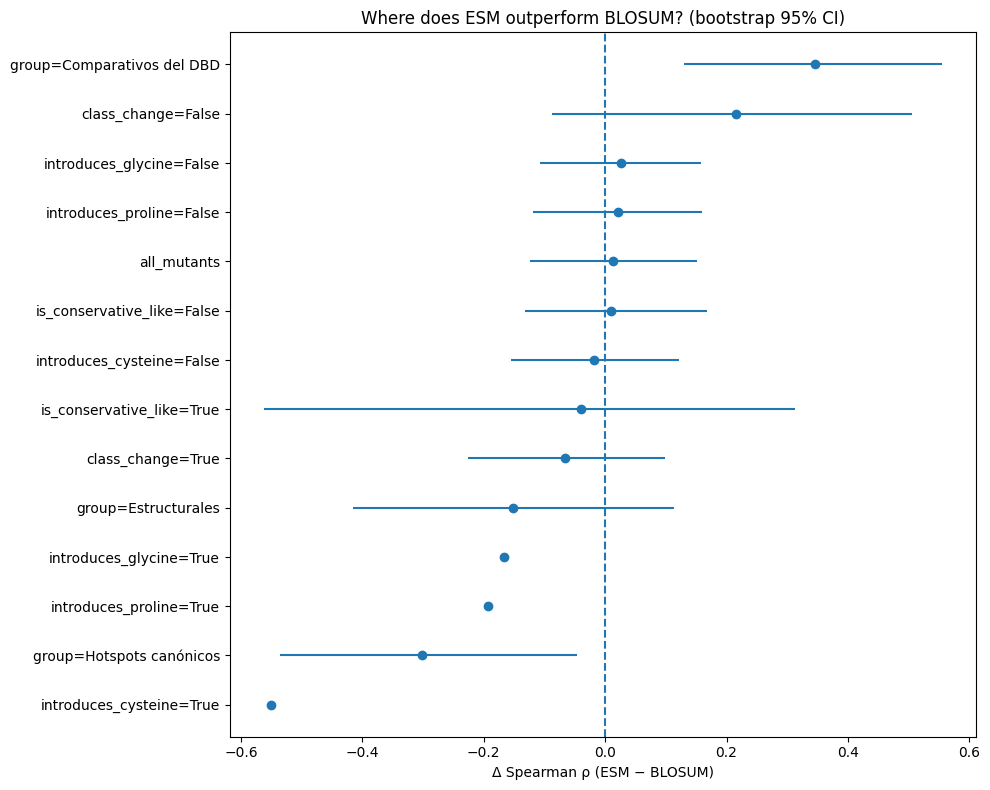

In [ ]:
# Bootstrap del delta de Spearman
bootstrap_rows = [{"subset": "all_mutants",
                   **bootstrap_delta_spearman(df_cmp, n_boot=2000)}]
for g, subdf in df_cmp.groupby("group"):
    bootstrap_rows.append({"subset": f"group={g}",
                           **bootstrap_delta_spearman(subdf, n_boot=2000)})
for col in ["class_change", "is_conservative_like", "introduces_glycine",
            "introduces_proline", "introduces_cysteine"]:
    for val in [True, False]:
        subdf = df_cmp[df_cmp[col] == val]
        bootstrap_rows.append({"subset": f"{col}={val}",
                               **bootstrap_delta_spearman(subdf, n_boot=2000)})
bootstrap_df = pd.DataFrame(bootstrap_rows).sort_values("delta_rho", ascending=False)

# Forest plot
tmp = bootstrap_df.dropna(subset=["delta_rho"]).sort_values("delta_rho", ascending=True)
plt.figure(figsize=(10, 8))
y = np.arange(len(tmp))
plt.errorbar(
    x=tmp["delta_rho"], y=y,
    xerr=[tmp["delta_rho"] - tmp["ci_low"], tmp["ci_high"] - tmp["delta_rho"]],
    fmt="o"
)
plt.yticks(y, tmp["subset"])
plt.axvline(0, linestyle="--")
plt.xlabel("Δ Spearman ρ (ESM − BLOSUM)")
plt.title("Where does ESM outperform BLOSUM? (bootstrap 95% CI)")
plt.tight_layout()
plt.show()


→ Figura final: subsets seleccionados


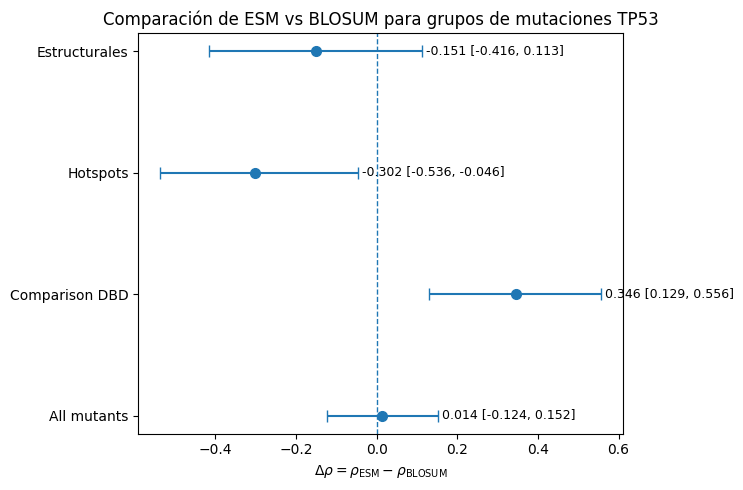

In [ ]:

# -- Figura final: subsets seleccionados --
print("\n→ Figura final: subsets seleccionados")
final_subsets = ["all_mutants", "group=Comparativos del DBD", "group=Hotspots canónicos", "group=Estructurales"]
final_df = bootstrap_df[bootstrap_df["subset"].isin(final_subsets)].copy()
label_map = {
    "all_mutants": "All mutants",
    "group=Comparativos del DBD": "Comparison DBD",
    "group=Hotspots canónicos": "Hotspots",
    "group=Estructurales": "Estructurales",
}
order_map = {k: i for i, k in enumerate(label_map)}
final_df["order"] = final_df["subset"].map(order_map)
final_df["label"] = final_df["subset"].map(label_map)
final_df = final_df.sort_values("order").reset_index(drop=True)

plt.figure(figsize=(7.5, 5))
_y = np.arange(len(final_df))
_x = final_df["delta_rho"].values
plt.errorbar(
    x=_x, y=_y,
    xerr=[_x - final_df["ci_low"].values,
          final_df["ci_high"].values - _x],
    fmt="o", capsize=4, markersize=7, linewidth=1.5,
)
plt.axvline(0, linestyle="--", linewidth=1)
for i, row in final_df.iterrows():
    txt = f"{row['delta_rho']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    plt.text(row["ci_high"] + 0.01, i, txt, va="center", fontsize=9)
plt.yticks(_y, final_df["label"])
plt.xlabel(r"$\Delta \rho = \rho_{\mathrm{ESM}} - \rho_{\mathrm{BLOSUM}}$")
plt.title("Comparación de ESM vs BLOSUM para grupos de mutaciones TP53")
plt.tight_layout()
plt.savefig("tp53_esm_vs_blosum_selected_subsets_corrected.svg")
plt.show()


→ Figura final: subsets seleccionados


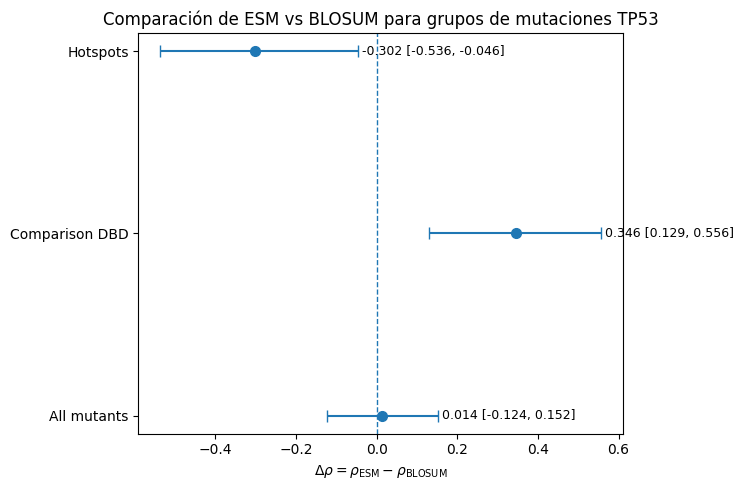

In [ ]:

# -- Figura final: subsets seleccionados --
print("\n→ Figura final: subsets seleccionados")
final_subsets = ["all_mutants", "group=Comparativos del DBD", "group=Hotspots canónicos"]
final_df = bootstrap_df[bootstrap_df["subset"].isin(final_subsets)].copy()
label_map = {
    "all_mutants": "All mutants",
    "group=Comparativos del DBD": "Comparison DBD",
    "group=Hotspots canónicos": "Hotspots",
}
order_map = {k: i for i, k in enumerate(label_map)}
final_df["order"] = final_df["subset"].map(order_map)
final_df["label"] = final_df["subset"].map(label_map)
final_df = final_df.sort_values("order").reset_index(drop=True)

plt.figure(figsize=(7.5, 5))
_y = np.arange(len(final_df))
_x = final_df["delta_rho"].values
plt.errorbar(
    x=_x, y=_y,
    xerr=[_x - final_df["ci_low"].values,
          final_df["ci_high"].values - _x],
    fmt="o", capsize=4, markersize=7, linewidth=1.5,
)
plt.axvline(0, linestyle="--", linewidth=1)
for i, row in final_df.iterrows():
    txt = f"{row['delta_rho']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    plt.text(row["ci_high"] + 0.01, i, txt, va="center", fontsize=9)
plt.yticks(_y, final_df["label"])
plt.xlabel(r"$\Delta \rho = \rho_{\mathrm{ESM}} - \rho_{\mathrm{BLOSUM}}$")
plt.title("Comparación de ESM vs BLOSUM para grupos de mutaciones TP53")
plt.tight_layout()
plt.savefig("tp53_esm_vs_blosum_selected_subsets.svg")
plt.show()


FASE 7: Comparación ESM2 vs BLOSUM62 como predictor de patogenicidad

Comparación ESM vs BLOSUM:
               label    n  spearman_rho  spearman_p  pearson_r  pearson_p  kendall_tau  kendall_p
0  BLOSUM62 vs score  228     -0.298836    0.000004  -0.286127   0.000011    -0.222308   0.000005
1   ESM k=5 vs score  228      0.312432    0.000001   0.229736   0.000471     0.217173   0.000001

Benchmark completo:
            label    n  spearman_rho  spearman_p  pearson_r  pearson_p  kendall_tau  kendall_p
0  BLOSUM62 (raw)  228      0.298836    0.000004   0.286127   0.000011     0.222308   0.000005
1      ESM global  228      0.234215    0.000361   0.222980   0.000696     0.159991   0.000325
2   ESM local k=5  228      0.312432    0.000001   0.229736   0.000471     0.217173   0.000001


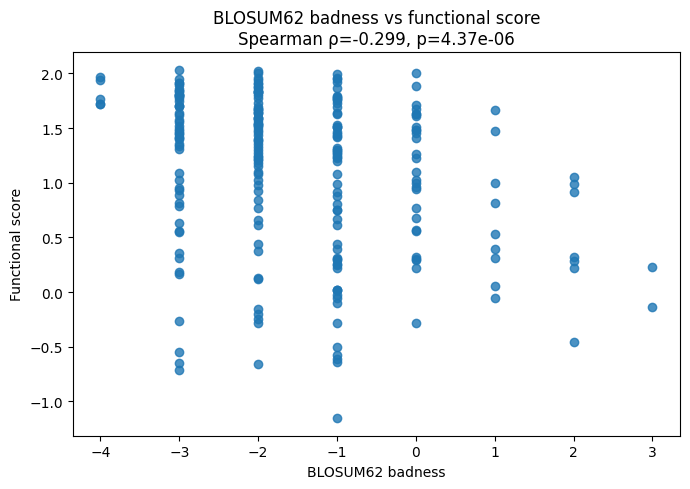

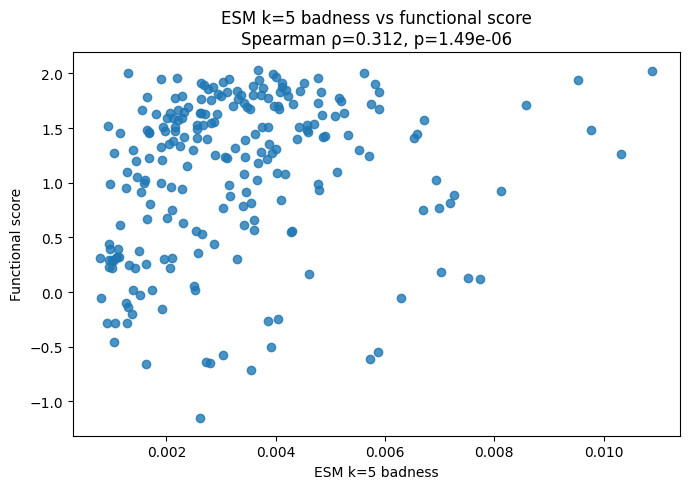

/tmp/ipykernel_9236/756076865.py:133: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])
/tmp/ipykernel_9236/756076865.py:133: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])
/tmp/ipykernel_9236/756076865.py:133: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r2, _ = spearmanr(s["blosum_badness"], s["target"])


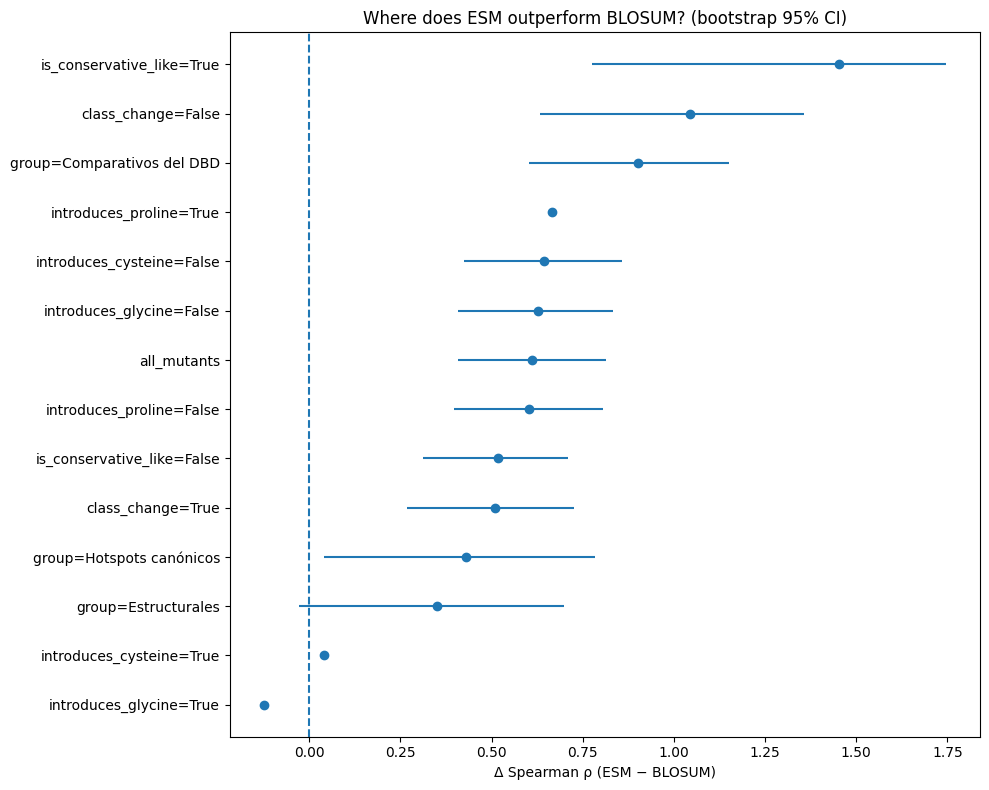


→ Figura final: subsets seleccionados


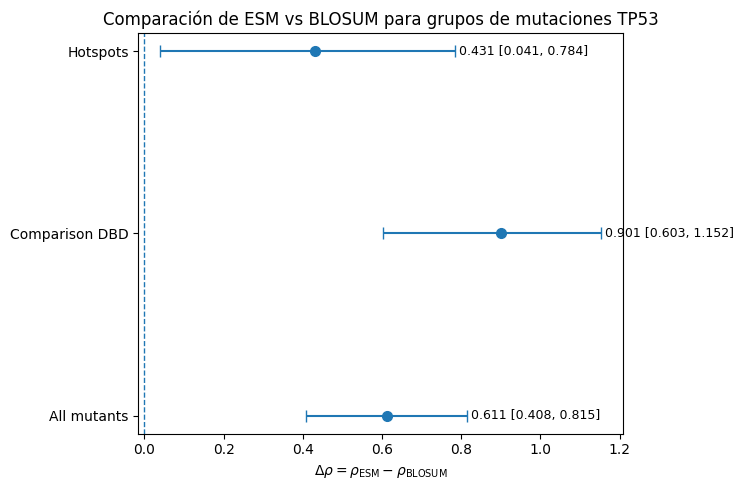


ANÁLISIS COMPLETO FINALIZADO

Archivos CSV generados:
  - metric_comparison.csv
  - compare_rank.csv
  - tp53_synthetic_mutants_embedding_metrics_annotated.csv
  - tp53_mannwhitney_k5_results.csv
  - tp53_mutation_type_summary_k5.csv
  - tp53_panel_functional_correlations.csv
  - tp53_panel_with_functional_scores.csv
  - tp53_panel_with_blosum.csv
  - tp53_benchmark_blosum_vs_esm.csv
  - tp53_esm_vs_blosum_subgroup_correlations.csv
  - tp53_esm_vs_blosum_bootstrap_delta_rho.csv

Archivos SVG generados:
  - metric_comparison_boxplot.svg
  - pca-global-embeddings.svg
  - pca-k5-embeddings.svg
  - tsne-global-embeddings.svg
  - tsne-k5-embeddings.svg
  - umap-global-embeddings.svg
  - average-sensitivity-by-position-global-vs-k5.svg
  - compare_rank.svg
  - boxplot-categories-vs-k5-cosine-distance.svg
  - mannwhitney-effect-sizes-k5-cosine.svg
  - embedding-vs-functional-score-k5.svg
  - embedding-vs-functional-score-global-k5.svg
  - histogram-embeding-shift.svg
  - tp53_esm_vs_blosum_s

In [ ]:



# Guardar tablas finales
all_subgroup_results = pd.concat([
    global_cmp.assign(kind="global"),
    group_results.assign(kind="group"),
    flag_results.assign(kind="flag"),
], ignore_index=True)
all_subgroup_results.to_csv("tp53_esm_vs_blosum_subgroup_correlations.csv", index=False)
bootstrap_df.to_csv("tp53_esm_vs_blosum_bootstrap_delta_rho.csv", index=False)
tp53_panel.to_csv("tp53_panel_with_blosum.csv", index=False)
benchmark_table.to_csv("tp53_benchmark_blosum_vs_esm.csv", index=False)

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETO FINALIZADO")
print("=" * 70)
print("\nArchivos CSV generados:")
print("  - metric_comparison.csv")
print("  - compare_rank.csv")
print("  - tp53_synthetic_mutants_embedding_metrics_annotated.csv")
print("  - tp53_mannwhitney_k5_results.csv")
print("  - tp53_mutation_type_summary_k5.csv")
print("  - tp53_panel_functional_correlations.csv")
print("  - tp53_panel_with_functional_scores.csv")
print("  - tp53_panel_with_blosum.csv")
print("  - tp53_benchmark_blosum_vs_esm.csv")
print("  - tp53_esm_vs_blosum_subgroup_correlations.csv")
print("  - tp53_esm_vs_blosum_bootstrap_delta_rho.csv")
print("\nArchivos SVG generados:")
print("  - metric_comparison_boxplot.svg")
print("  - pca-global-embeddings.svg")
print("  - pca-k5-embeddings.svg")
print("  - tsne-global-embeddings.svg")
print("  - tsne-k5-embeddings.svg")
print("  - umap-global-embeddings.svg")
print("  - average-sensitivity-by-position-global-vs-k5.svg")
print("  - compare_rank.svg")
print("  - boxplot-categories-vs-k5-cosine-distance.svg")
print("  - mannwhitney-effect-sizes-k5-cosine.svg")
print("  - embedding-vs-functional-score-k5.svg")
print("  - embedding-vs-functional-score-global-k5.svg")
print("  - histogram-embeding-shift.svg")
print("  - tp53_esm_vs_blosum_selected_subsets.svg")
